In [1]:
import pandas as pd
import numpy as np
from adjustText import adjust_text
from matplotlib import pyplot as plt
from matplotlib import colors
import statsmodels.api as sm
import statsmodels.formula.api as smf
from tqdm import tqdm
import re
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from umap import umap_ as UMAP
import os
import gseapy as gp
import networkx as nx
from gseapy import GSEA
import decoupler as dc
from scipy.stats import zscore


## Reading files in

Since all of this is in a docker container I'll redirect to the attached container.

In [4]:
print(os.getcwd())
print(os.listdir())
os.chdir(r"work/")
print(os.listdir())
os.chdir(r"Olink")
print(os.listdir())

/home/jovyan
['.bashrc', '.profile', '.bash_logout', '.npm', '.local', '.cache', '.ipython', '.config', '.jupyter', '.conda', '.wget-hsts', 'work']
['ALE06_Subject_PCAs.csv', 'Bioplex', 'Completeness', 'Cytof', 'FCS', 'NovaSeq', 'Olink', 'Sequencing_1', 'Viral']
['ALE06_Metadata.xlsx', 'ALE06_pca_with_1kg.txt', 'ALE06_Subject_PCAs.csv', 'All_Present_Subjects_w_demographics.csv', 'Comp_GSEA_Beta_Rank.csv', 'Figures', 'Flare_Comps_Volcano_WO_Labels.png', 'Flare_Comps_Volcano_W_Labels.png', 'Gene_Comparisons.xlsx', 'Level_2_SDP.parquet', 'Maintenance_Flare_Comparison_LMER_output.csv', 'Maintenance_MM_Flare_LMER_output.csv', 'Maintenance_Overall_Flare_LMER_output.csv', 'Maintenance_Regression_Frame.csv', 'Maintenance_Severe_Flare_LMER_output.csv', 'Manually_Ranked_GSEA_Example.ipynb', 'Mild_Moderate_Flarers_Network.png', 'MM_GSEA_P_Rank.csv', 'MM_LEMR_Volcano_WO_Labels.png', 'MM_LEMR_Volcano_W_Labels.png', 'OLINK_LMER.ipynb', 'OLINK_LMER_Output_Analysis.ipynb', 'OLINK_Serum_Manifest.xlsx',

In [5]:
### All of these dataframes were constructed in the "OLINK_LMER.ipynb" script
All_present_subjects = pd.read_csv("All_Present_Subjects_w_demographics.csv", dtype={'Subject_ID': object})
Overall_Maintenance_Regression_outputs = pd.read_csv("Maintenance_Overall_Flare_LMER_output.csv")
Overall_Withdrawal_Regression_outputs = pd.read_csv("Withdrawal_Overall_Flare_LMER_output.csv")
Maintenance_MM_Regression_outputs = pd.read_csv("Maintenance_MM_Flare_LMER_output.csv")
Withdrawal_MM_Regression_outputs = pd.read_csv("Withdrawal_MM_Flare_LMER_output.csv")
Maintenance_Severe_Regression_outputs = pd.read_csv("Maintenance_Severe_Flare_LMER_output.csv")
Withdrawal_Severe_Regression_outputs = pd.read_csv("Withdrawal_Severe_Flare_LMER_output.csv")
Maintenenace_Comparison_Frame=pd.read_csv("Maintenance_Flare_Comparison_LMER_output.csv")
Withdrawal_Comparison_Frame=pd.read_csv("Withdrawal_Flare_Comparison_LMER_output.csv")

## Exploring the results.

### Plotting results in a volcano plot

In [20]:
def Volcano(Graphing_frame, percentile=None, savepath=None):
    transformed_Pvals=-np.log10(Graphing_frame["P-Value"])
    fig, ax = plt.subplots(figsize=[10,10])
    plt.xlabel("Beta Value")
    plt.ylabel("-Log10 P value")
    col=np.where(Graphing_frame["P-Value"]>.05,"gray",np.where(np.absolute(Graphing_frame["Beta"])>.05,np.where(Graphing_frame["Beta"]>.05,"r","b"),"gray"))
    ax.axhline(y=-np.log10(.05), linestyle="--",color="black")
    ax.axvline(x=-.05, linestyle="--",color="black")
    ax.axvline(x=.05, linestyle="--",color="black")
    ax.scatter(Graphing_frame["Beta"], transformed_Pvals,color=col,s=2)
    # ax.set_xlim(xmin=-2.5, xmax=2.5)
    # ax.set_ylim(ymin=-0.5, ymax=2)
    fig.suptitle("LME results for Weeks 0, 4, 12, and 20", fontsize=16)
    # for i,r in res[Overall_filter].iterrows():
        # ax.text(x=r["log2FoldChange"],y=-np.log10(r["padj"]),s=i)
    if percentile:
        print("Top "+str(percentile)+" Percintile shown")
        text_bool=np.array(transformed_Pvals>np.quantile(transformed_Pvals,[percentile])[0])
        to_be_labled=Graphing_frame[text_bool]
        texts=[plt.text(x=f,y=p,s=i,fontsize=7.5) for i,f,p in zip(to_be_labled["Protein"],to_be_labled["Beta"],transformed_Pvals[text_bool])]
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'))
    if savepath:
        plt.savefig(savepath)

### Maintenance Plots

#### Overall Flares

Top 0.99 Percintile shown


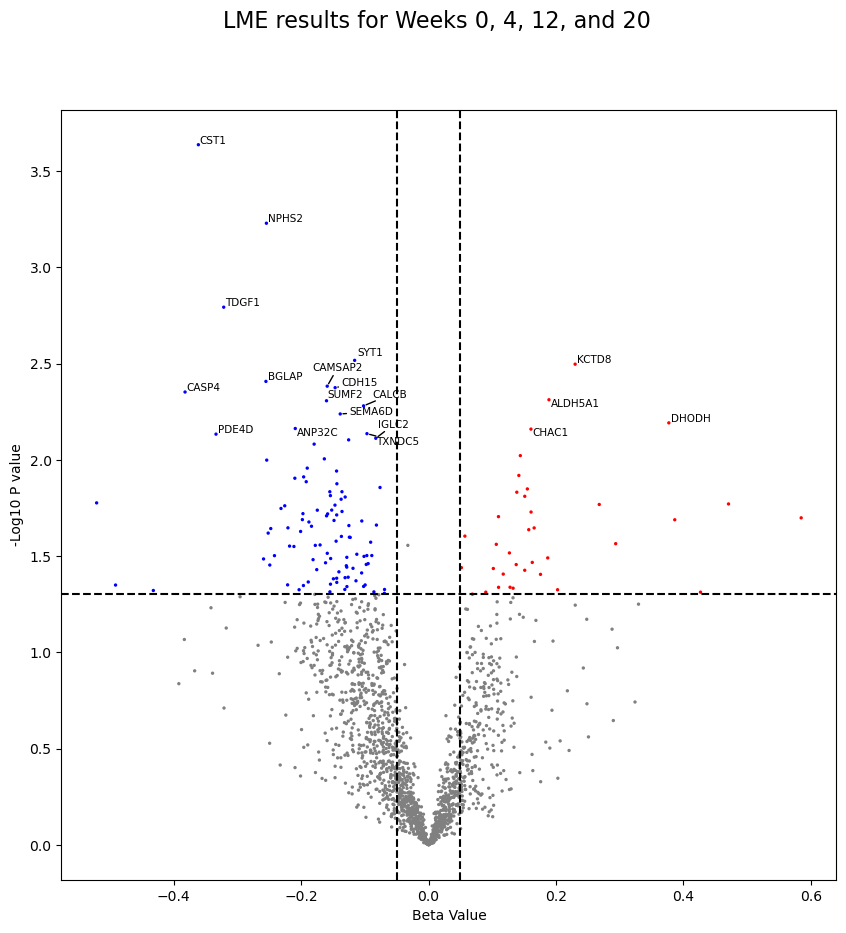

In [21]:
Volcano(Overall_Maintenance_Regression_outputs,percentile=.99)

#### Mild Moderate Flares

Top 0.99 Percintile shown


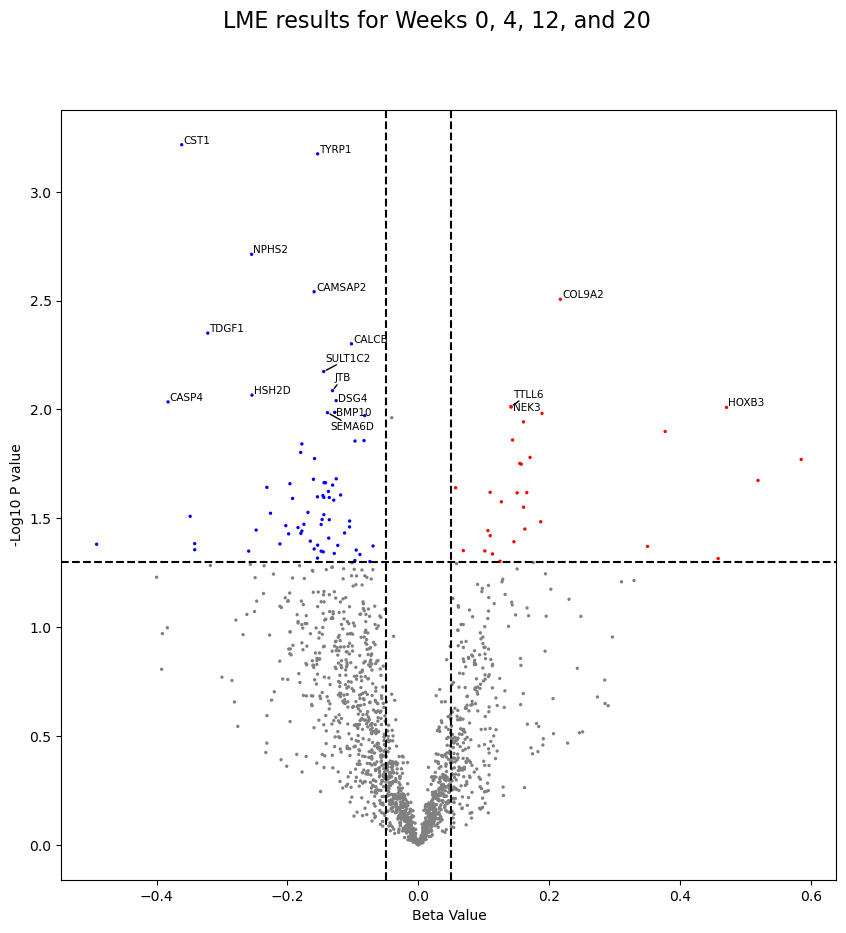

In [22]:
Volcano(Maintenance_MM_Regression_outputs,percentile=.99)

#### Severe Flares

In [51]:
Maintenance_Severe_Regression_outputs[Maintenance_Severe_Regression_outputs["P-Value"].isna()]

,Protein,P-Value,Beta
38,ACSL1,NaN,-0.177888
2501,MDK,NaN,0.001143
4306,WDHD1,NaN,0.252934


I'll just remove these I guess.

In [52]:
Maintenance_Severe_Regression_outputs=Maintenance_Severe_Regression_outputs[~Maintenance_Severe_Regression_outputs["P-Value"].isna()]

Top 0.98 Percintile shown


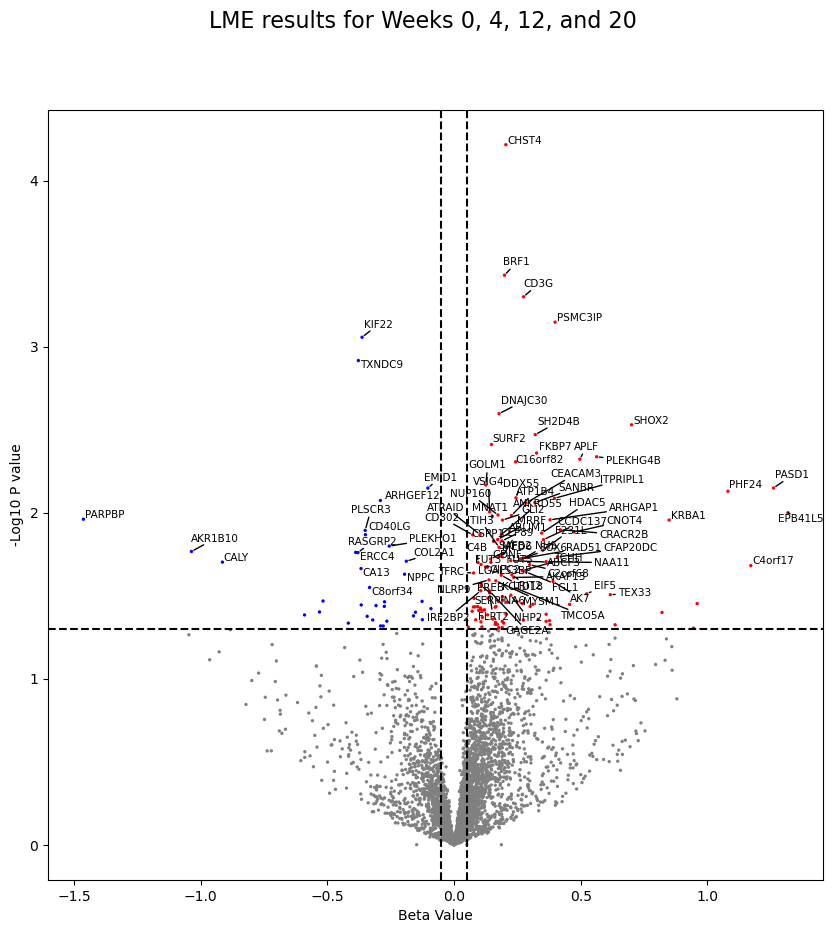

In [54]:
Volcano(Maintenance_Severe_Regression_outputs,percentile=.98)

#### Flare Comparisons (Severe vs Mild Moderate)

Top 0.99 Percintile shown


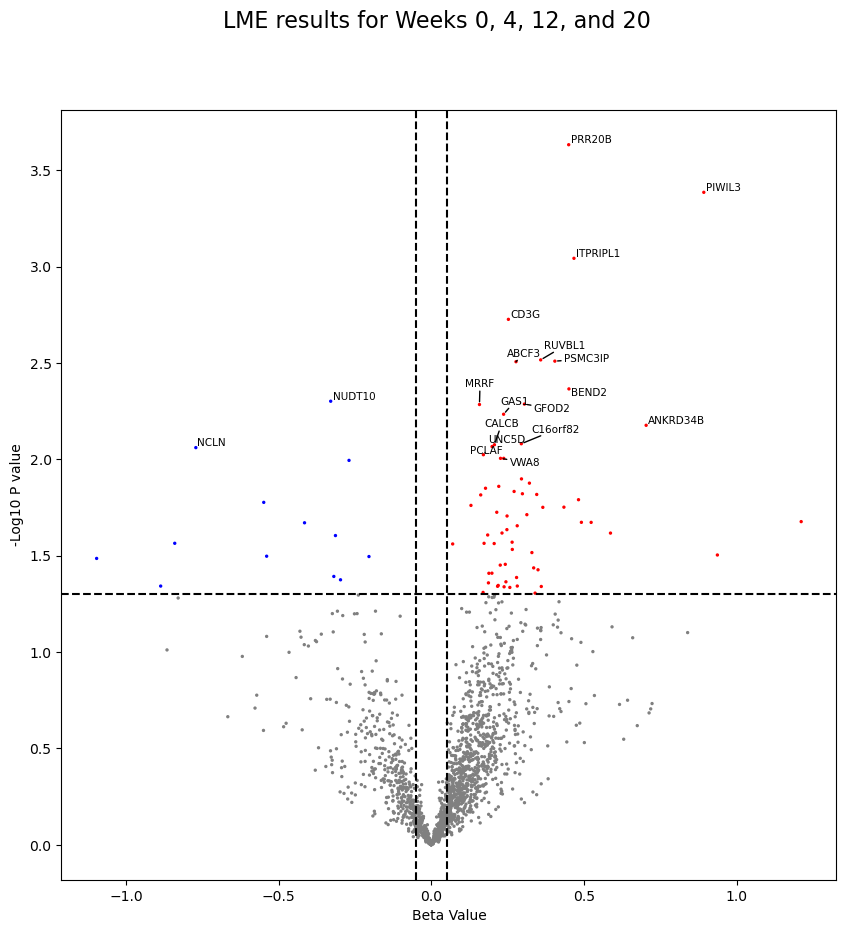

In [26]:
Volcano(Maintenenace_Comparison_Frame,percentile=.99)

### Withdrawal Plots

#### Overall Flares

Top 0.99 Percintile shown


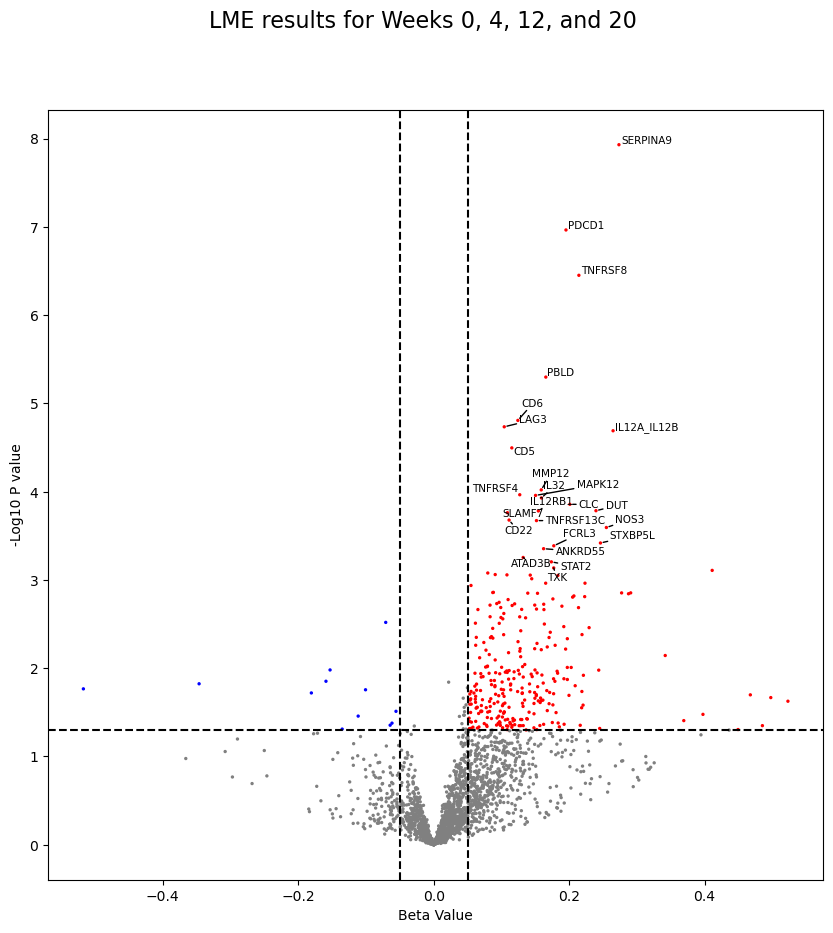

In [55]:
Volcano(Overall_Withdrawal_Regression_outputs,percentile=.99)

#### Mild Moderate Flares

Top 0.99 Percintile shown


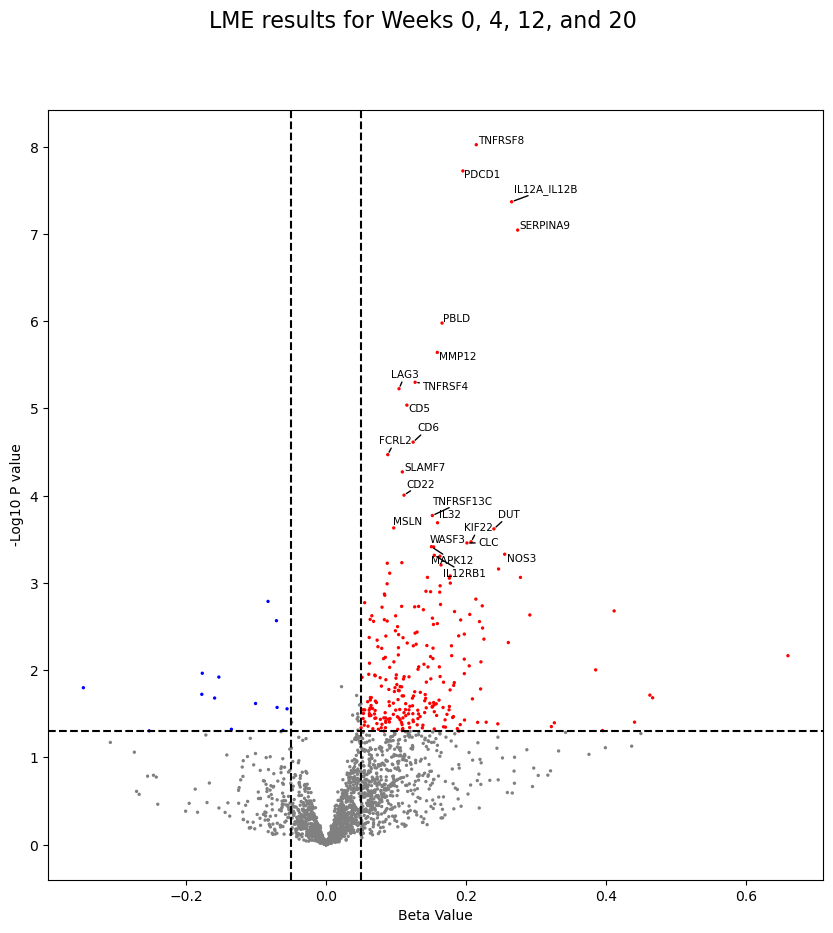

In [56]:
Volcano(Withdrawal_MM_Regression_outputs,percentile=.99)

#### Severe Flares

Top 0.994 Percintile shown


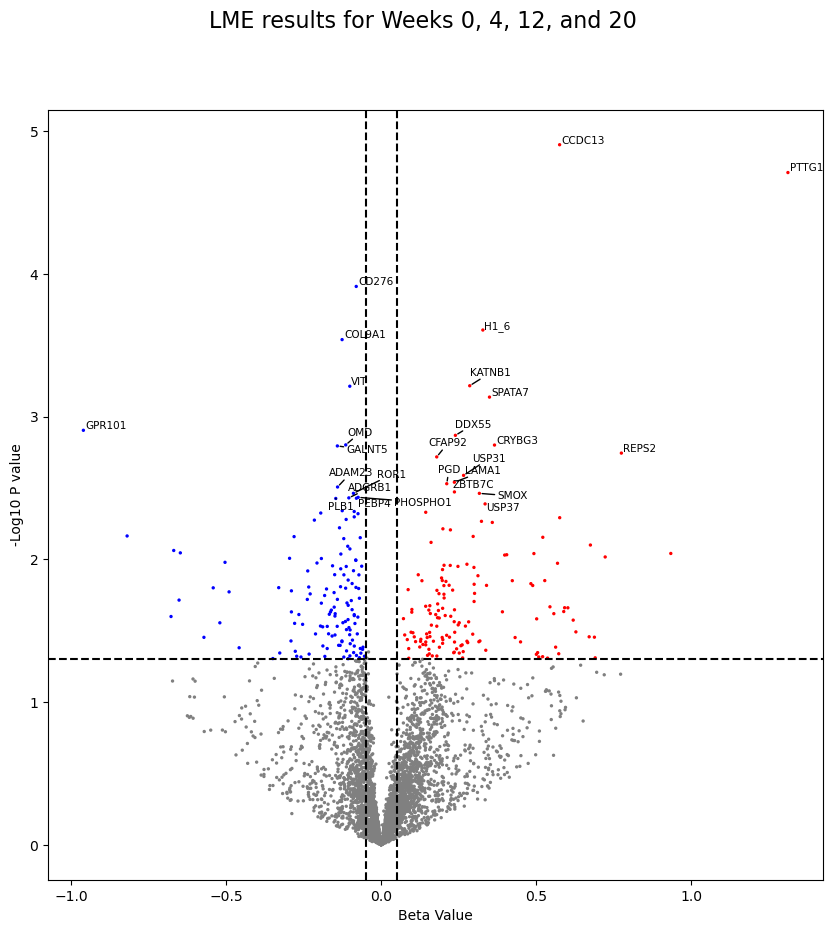

In [58]:
Volcano(Withdrawal_Severe_Regression_outputs,percentile=.994)

#### Flare Comparisons (Severe vs Mild Moderate)

Top 0.99 Percintile shown


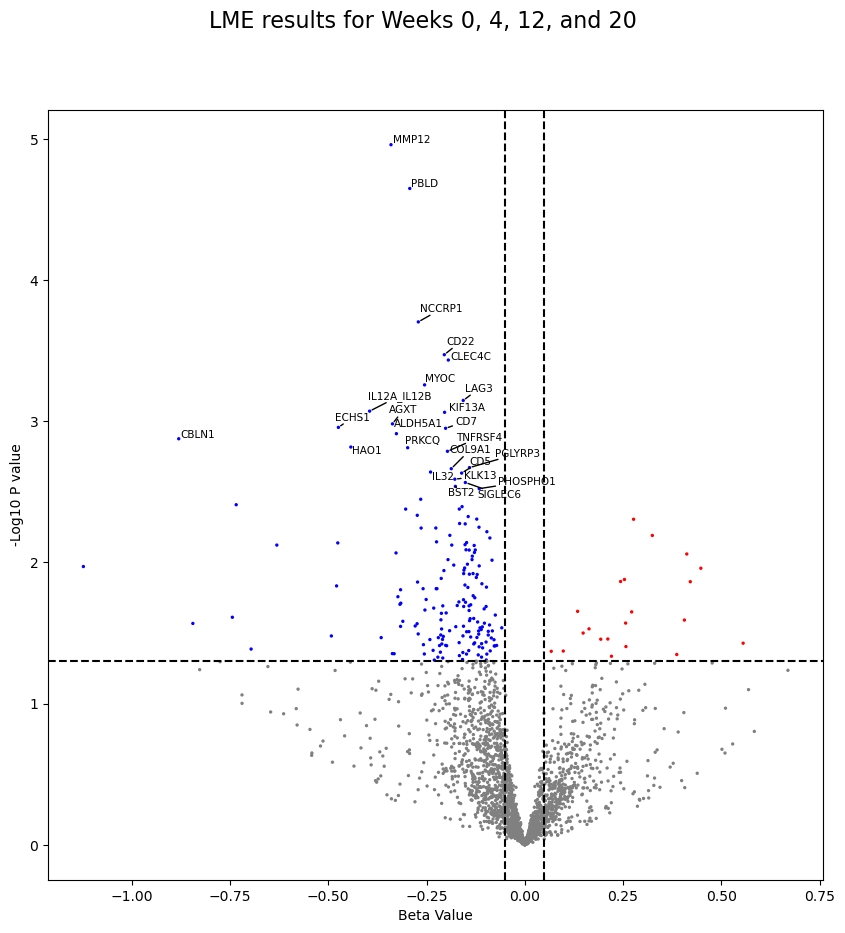

In [59]:
Volcano(Withdrawal_Comparison_Frame,percentile=.99)

In [16]:
All_present_subjects["Visit_ID"].unique()

array(['Day 0', 'Week 4', 'Week 12', 'Week 16', 'Week 20', 'Week 40',
       'Week 24', 'Week 32', 'Week 48', 'Week 60', 'Endpoint', 'Flare'],
      dtype=object)

In [35]:
Subject_Bool=[x in set(Wanted_Subjects["Subject_ID"]) for x in All_present_subjects["Subject_ID"]]

In [36]:
type(Wanted_Subjects["Subject_ID"][0])

str

In [453]:
Weekly_expression=All_present_subjects[Subject_Bool][["CD27",'Subject_ID','Visit_ID']].groupby(['Subject_ID','Visit_ID']).mean()
Weekly_expression.reset_index(inplace=True)
Weekly_expression

,Subject_ID,Visit_ID,CD27
0,010021,Day 0,16.073382
1,010021,Week 12,16.809124
2,010021,Week 20,16.683523
3,010021,Week 32,16.872409
4,010021,Week 4,14.853863
...,...,...,...
198,960076,Week 20,14.785521
199,960076,Week 32,14.536450
200,960076,Week 4,14.878180
201,960076,Week 40,14.242454


In [454]:
Visit_map={"Day 0":1,"Week 4":2,"Week 12":3,"Week 20":4}

In [455]:
Weekly_expression["Visit_Number"]=Weekly_expression["Visit_ID"].map(Visit_map)
Only_Taper=Weekly_expression[~Weekly_expression["Visit_Number"].isna()]
Only_Taper

,Subject_ID,Visit_ID,CD27,Visit_Number
0,010021,Day 0,16.073382,1.0
1,010021,Week 12,16.809124,3.0
2,010021,Week 20,16.683523,4.0
4,010021,Week 4,14.853863,2.0
7,010032,Day 0,14.635038,1.0
...,...,...,...,...
193,960021,Week 4,15.441602,2.0
196,960076,Day 0,14.548467,1.0
197,960076,Week 12,14.056478,3.0
198,960076,Week 20,14.785521,4.0


In [456]:
Only_Taper["Subject_ID"].unique()

array(['010021', '010032', '070037', '080016', '080064', '080081',
       '120021', '120059', '120087', '120098', '140013', '140056',
       '140078', '140112', '140134', '580011', '590023', '650079',
       '650085', '650100', '650158', '820039', '820091', '890113',
       '890124', '930039', '950055', '960021', '960076'], dtype=object)

In [457]:
len(Wanted_Subjects)

29

In [458]:
All_present_subjects

,A1BG,AAAS,AAGAB,AAMDC,AARSD1,AASDH,ABCA2,ABCB5,ABCC6,ABCC8,...,PC4,PC5,PC6,ARM,Flare_Status,Subject_ID,Visit_ID,Overall_Flare,Sex,Age
0,16.991027,8.208178,8.704062,11.701449,12.455014,7.451000,7.584085,7.740132,9.340608,9.281852,...,0.001341,0.001780,-0.001586,Withdrawal,MM Flare,650100,Day 0,Flare,F,67.0
1,15.964322,11.213881,9.094070,13.566242,16.059973,8.117424,4.658547,7.682511,9.455263,6.462063,...,0.005510,0.001824,-0.002852,Maintenance,MM Flare,950014,Day 0,Flare,M,45.0
2,16.364716,8.125629,8.432377,11.909549,13.104989,6.903450,8.651963,9.226216,10.631772,8.631710,...,0.005482,-0.000554,-0.003680,Withdrawal,No Flare,950020,Day 0,No Flare,F,59.0
3,16.677855,7.226470,8.677316,11.726395,12.025327,5.486360,7.940571,9.122702,11.140813,7.255495,...,-0.001734,0.000004,0.010346,Maintenance,MM Flare,890031,Day 0,Flare,M,40.0
4,17.153621,8.911221,7.328516,11.590179,11.275461,5.458785,8.595910,10.924739,13.813331,10.073720,...,-0.027909,0.000421,0.003569,Withdrawal,MM Flare,140056,Day 0,Flare,F,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,16.354342,7.789045,8.257148,11.270789,13.553704,5.666520,9.156877,8.199811,9.503979,7.952014,...,0.001424,0.005616,-0.000904,Maintenance,Severe Flare,820045,Endpoint,Flare,F,19.0
516,16.223642,10.153795,7.908710,11.973792,12.315528,5.439645,8.087549,8.104013,9.287629,8.845104,...,0.001427,-0.000079,0.006871,Withdrawal,Severe Flare,890124,Week 60,Flare,F,39.0
517,17.113829,10.196122,9.724068,13.525784,12.394214,8.136231,9.259670,9.518011,11.121142,6.880308,...,-0.006303,-0.000731,0.015338,Withdrawal,Severe Flare,070037,Flare,Flare,F,28.0
518,16.847853,8.353274,7.918339,12.905347,14.578933,8.272570,8.763918,9.800906,10.569836,8.638599,...,0.001821,0.004289,-0.000792,Maintenance,MM Flare,080038,Week 4,Flare,F,37.0


In [459]:
Flaremap={"No Flare":"g","MM Flare":"orange","Severe Flare":"r"}
Graph_Color_Map={x:pd.Series(All_present_subjects[All_present_subjects["Subject_ID"]==x]["Flare_Status"].unique()).map(Flaremap)[0] for x in All_present_subjects["Subject_ID"].unique()}

In [64]:
Graph_Color_Map

{'650100': 'orange',
 '950014': 'orange',
 '950020': 'g',
 '890031': 'orange',
 '140056': 'orange',
 '650057': 'g',
 '140013': 'orange',
 '650040': 'g',
 '820028': 'g',
 '960032': 'g',
 '650111': 'g',
 '120087': 'orange',
 '120021': 'orange',
 '060036': 'g',
 '120032': 'r',
 '060047': 'g',
 '650034': 'orange',
 '590034': 'g',
 '590023': 'orange',
 '120010': 'orange',
 '080038': 'orange',
 '080016': 'orange',
 '070071': 'orange',
 '140095': 'g',
 '820039': 'orange',
 '930017': 'g',
 '140078': 'orange',
 '070015': 'orange',
 '140123': 'g',
 '650085': 'orange',
 '890066': 'g',
 '080081': 'r',
 '890099': 'g',
 '070048': 'g',
 '080064': 'orange',
 '930045': 'g',
 '650079': 'orange',
 '100023': 'g',
 '140101': 'g',
 '650096': 'g',
 '890020': 'g',
 '100096': 'g',
 '590012': 'r',
 '930039': 'orange',
 '120059': 'orange',
 '890102': 'orange',
 '570032': 'g',
 '960059': 'g',
 '060050': 'g',
 '140112': 'r',
 '120065': 'orange',
 '890055': 'orange',
 '120076': 'g',
 '120043': 'orange',
 '960076': 

In [74]:
['SERPINA9',
 'TNFRSF8',
 'DUT',
 'PDCD1',
 'MSLN',
 'TXK',
 'CD6',
 'STXBP5L',
 'LAIR2',
 'NOS3']

['SERPINA9',
 'TNFRSF8',
 'DUT',
 'PDCD1',
 'MSLN',
 'TXK',
 'CD6',
 'STXBP5L',
 'LAIR2',
 'NOS3']

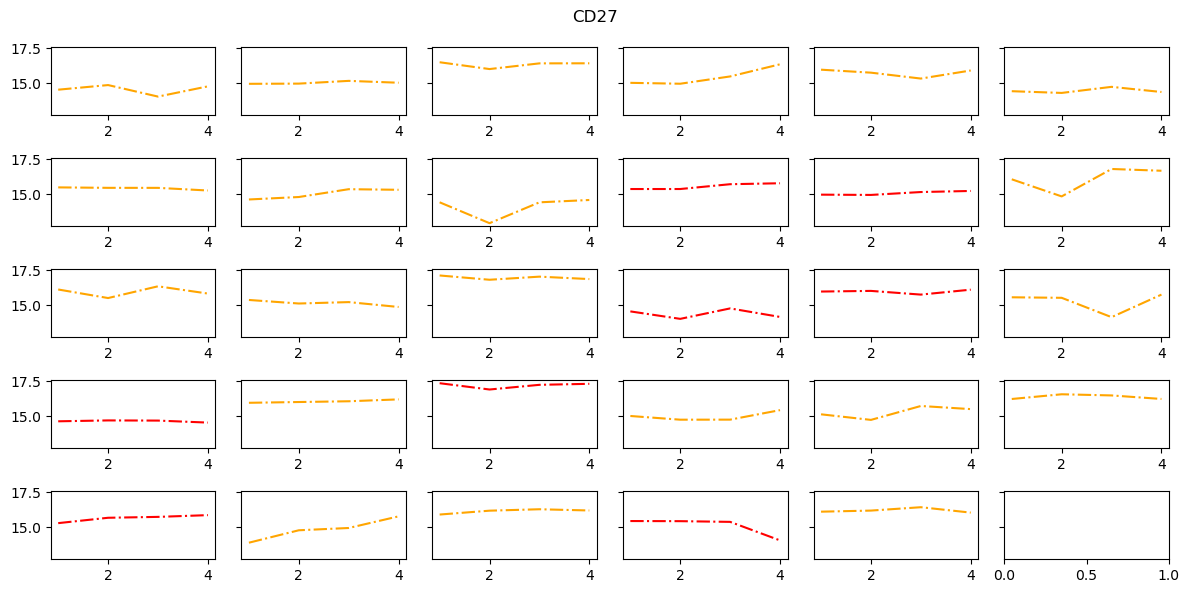

In [460]:
protein="CD27"
fig, axs = plt.subplots(5,6, sharey=True,figsize=(12,6))
r=0
col=0
for Subject in Wanted_Subjects["Subject_ID"]:
    if col<6:
        Subject_Frame=Only_Taper[Only_Taper["Subject_ID"]==Subject][[protein,"Visit_Number"]].sort_values(by="Visit_Number")
        
        currrent_color=Graph_Color_Map[Subject]
        axs[r,col].plot(Subject_Frame["Visit_Number"], Subject_Frame[protein], '-.', label=Subject, c=currrent_color)
        col+=1
    else:
        r+=1
        col=0
        currrent_color=Graph_Color_Map[Subject]
        Subject_Frame=Only_Taper[Only_Taper["Subject_ID"]==Subject][[protein,"Visit_Number"]].sort_values(by="Visit_Number")
        axs[r,col].plot(Subject_Frame["Visit_Number"], Subject_Frame[protein], '-.', label=Subject, c=currrent_color)
        col+=1
fig.suptitle(protein)
fig.tight_layout()

In [ ]:
for protein in proteinlist:
    NoFlare=Only_Taper[Only_Taper["Overall_Flare"]=="No Flare"][[protein,"Visit_Number"]].sort_values(by="Visit_Number")
    Flare=Only_Taper[Only_Taper["Overall_Flare"]=="Flare"][[protein,"Visit_Number"]].sort_values(by="Visit_Number")

    fig, axs = plt.subplots(1,2, sharey=True,figsize=(12,6))

    axs[0].plot(NoFlare["Visit_Number"], NoFlare[protein], '-.', col='g', label='No Flare')
    axs[0].set_title("No Flare")

    axs[1].plot(Flare["Visit_Number"], Flare[protein], '-', col='r', label='Flare')
    axs[1].set_title("Flare")

    fig.suptitle(protein)
    fig.tight_layout()

In [ ]:
protein_filter=[x in set(Overall_Regression_outputs[Overall_Regression_outputs["P-Value"]<.05]["Protein"]) for x in All_present_subjects.columns]

In [ ]:
Week_20_Withdrawal_filter=np.array(((All_present_subjects["Visit_ID"]=="Week 20")&(All_present_subjects["ARM"]=="Withdrawal")))

In [ ]:
Reduction_DF=All_present_subjects.iloc[Week_20_Withdrawal_filter,protein_filter]
Reduction_DF.shape

In [ ]:
pca = PCA(n_components=3, svd_solver='full')

pca.fit(Reduction_DF.T)

print(pca.explained_variance_ratio_)

In [ ]:
UMAP_df = UMAP(n_components=2, init='random', random_state=0).fit_transform(Reduction_DF)

UMAP_df

In [ ]:
pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2"])

In [ ]:
UMAP_Frame=All_present_subjects[Week_20_Withdrawal_filter]
UMAP_Frame["UMAP1"]=pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2"])["UMAP1"].tolist()
UMAP_Frame["UMAP2"]=pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2"])["UMAP2"].tolist()
fig = px.scatter(UMAP_Frame, x='UMAP1', y='UMAP2',
              color='Flare_Status')
fig.show()

In [ ]:
UMAP_df = UMAP(n_components=3, init='random', random_state=0).fit_transform(Reduction_DF)

UMAP_df

In [ ]:
pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2","UMAP3"])

In [ ]:
UMAP_Frame=All_present_subjects[Week_20_Withdrawal_filter]
UMAP_Frame["UMAP1"]=pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2","UMAP3"])["UMAP1"].tolist()
UMAP_Frame["UMAP2"]=pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2","UMAP3"])["UMAP2"].tolist()
UMAP_Frame["UMAP3"]=pd.DataFrame(UMAP_df, columns=["UMAP1","UMAP2","UMAP3"])["UMAP3"].tolist()
fig = px.scatter_3d(UMAP_Frame, x='UMAP1', y='UMAP2', z='UMAP3',
              color='Flare_Status')
fig.show()

In [ ]:
pd.DataFrame(pca.components_.T, columns=["PC1","PC2","PC3"])

In [ ]:
PCA_Frame=All_present_subjects[Week_20_Withdrawal_filter]
PCA_Frame["Transcript_PC1"]=pd.DataFrame(pca.components_.T, columns=["PC1","PC2","PC3"])["PC1"].tolist()
PCA_Frame["Transcript_PC2"]=pd.DataFrame(pca.components_.T, columns=["PC1","PC2","PC3"])["PC2"].tolist()
PCA_Frame["Transcript_PC3"]=pd.DataFrame(pca.components_.T, columns=["PC1","PC2","PC3"])["PC3"].tolist()

In [ ]:
fig = px.scatter(PCA_Frame, x='Transcript_PC1', y='Transcript_PC2',
              color='Flare_Status')
fig.show()

In [ ]:
fig = px.scatter_3d(PCA_Frame, x='PC1', y='PC2', z='PC3',
              color='Flare_Status')
fig.show()

# Pathway Analysis

#### Reading in the reference databases.

In [60]:
def Reshape_GSEApy_Genesets(list_of_genesets):
    total_libraries=None
    for geneset in list_of_genesets:
        geneset_dict=gp.get_library(name=geneset, organism='Human')
        print(geneset)
        if type(total_libraries)!=None:
            df = pd.concat(pd.DataFrame({'source':k, 'target':v}) for k, v in geneset_dict.items())
            # df['index'] = df.groupby('name').cumcount().add(1)
            df["Library"]=geneset
            total_libraries=pd.concat([total_libraries,df])
        else:
            total_libraries = pd.concat(pd.DataFrame({'source':k, 'target':v}) for k, v in geneset_dict.items())
            # total_libraries['index'] = df.groupby('name').cumcount().add(1)
            total_libraries["Library"]=geneset
    return total_libraries.reset_index(drop=True)

In [61]:
names = gp.get_library_name(organism='Human')
names

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_CRISPR_GeneDependency_CellLines_2023',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_Cell

In [62]:
# geneset_choices=["GO_Biological_Process_2023","Human_Gene_Atlas","WikiPathways_2019_Human","KEGG_2021_Human","GO_Cellular_Component_2023","GO_Molecular_Function_2023"]
geneset_choices=["GO_Biological_Process_2023","WikiPathways_2019_Human","KEGG_2021_Human","GO_Cellular_Component_2023","GO_Molecular_Function_2023"]
# geneset_choices=["GO_Biological_Process_2023"]

In [63]:
decoupler_frame=Reshape_GSEApy_Genesets(geneset_choices)
decoupler_frame

GO_Biological_Process_2023
WikiPathways_2019_Human
KEGG_2021_Human
GO_Cellular_Component_2023
GO_Molecular_Function_2023


,source,target,Library
0,'De Novo' AMP Biosynthetic Process (GO:0044208),ATIC,GO_Biological_Process_2023
1,'De Novo' AMP Biosynthetic Process (GO:0044208),PAICS,GO_Biological_Process_2023
2,'De Novo' AMP Biosynthetic Process (GO:0044208),PFAS,GO_Biological_Process_2023
3,'De Novo' AMP Biosynthetic Process (GO:0044208),ADSS1,GO_Biological_Process_2023
4,'De Novo' AMP Biosynthetic Process (GO:0044208),ADSS2,GO_Biological_Process_2023
...,...,...,...
302737,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A8,GO_Molecular_Function_2023
302738,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A3,GO_Molecular_Function_2023
302739,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A2,GO_Molecular_Function_2023
302740,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A5,GO_Molecular_Function_2023


### Perform GSEA on all Flarers

In [93]:
MM_gsea=MM_Regression_outputs.set_index("Protein")
MM_gsea["-LogP"]=-np.log10(MM_gsea["P-Value"])
MM_gsea

,P-Value,Beta,Ranking,-LogP
Protein,,,,
AAAS,0.221669,-0.124040,-0.081159,0.654296
AAGAB,0.280155,0.086447,0.047771,0.552601
AARSD1,0.583272,0.046508,0.010889,0.234129
ABCC6,0.136155,0.122136,0.105765,0.865966
ABCC8,0.856972,0.015087,0.001011,0.067033
...,...,...,...,...
ZNRF4,0.343350,-0.240185,-0.111509,0.464263
ZP3,0.420126,0.111260,0.041903,0.376620
ZPR1,0.710611,0.025522,0.003787,0.148368


In [65]:
def Get_Pathways(RankingFrame, PathwayFrame, Ranking_Metric, saveloc=None):
    #### Protein names must be the index of the Frame.
    filtered_Pathway_frame=PathwayFrame[PathwayFrame["target"].isin(set(RankingFrame.index))]
    GSEA_Frame=dc.get_gsea_df(df=RankingFrame,stat=Ranking_Metric, net=filtered_Pathway_frame,source="source",target="target")
    GSEA_Frame["Absolute_NES"]=np.absolute(GSEA_Frame["NES"])
    if saveloc:
        GSEA_Frame.to_csv(saveloc)
    return GSEA_Frame

def Iterative_running_Score(PathwayFrame, RankingFrame, paths_of_interest, Ranking_Metric, save=None):
    for x in paths_of_interest:
        dc.plot_running_score(
            df=RankingFrame,
            stat=Ranking_Metric,
            net=PathwayFrame,
            source='source',
            target='target',
            set_name=x,
            save=save
        )

def Plot_Network(GSEA_Frame,
                 RankingFrame, 
                 TargetMetric, 
                 SourceMetric, 
                 PathwayFrame, 
                 Paths_to_graph,
                 proteins=10,
                 node_size=50,
                 t_cmap='viridis',
                 s_cmap='RdBu_r',
                 labelsize=8,
                 layout="rt_circular",
                 s_label="Normalized Erichment Score",
                 t_label="Protein Change over taper",
                 save=None,
                 ):
                    filtered_Pathway_frame=PathwayFrame[PathwayFrame["target"].isin(set(RankingFrame.index))]
                    Target_series=RankingFrame[[TargetMetric]].T.rename(index={TargetMetric: 'Systemic'})
                    Source_series=GSEA_Frame.set_index("Term")[[SourceMetric]].T.rename(index={SourceMetric: 'Systemic'})
                    dc.plot_network(
                        net=filtered_Pathway_frame,
                        obs=Target_series,
                        act=Source_series,
                        n_sources=Paths_to_graph,
                        n_targets=proteins,
                        node_size=node_size,
                        s_cmap=s_cmap,
                        t_cmap=t_cmap,
                        c_pos_w='gray',
                        c_neg_w='gray',
                        figsize=(10, 10),
                        label_size=labelsize,
                        layout=layout,
                        s_label=s_label,
                        t_label=t_label,
                        save=save
                    )

In [94]:
filtered_decoupler_frame=decoupler_frame[decoupler_frame["target"].isin(set(MM_gsea.index))]
filtered_decoupler_frame

,source,target,Library
11,'De Novo' Post-Translational Protein Folding (...,ENTPD5,GO_Biological_Process_2023
19,'De Novo' Post-Translational Protein Folding (...,DNAJB14,GO_Biological_Process_2023
31,'De Novo' Post-Translational Protein Folding (...,HSPA13,GO_Biological_Process_2023
67,3'-UTR-mediated mRNA Stabilization (GO:0070935),DAZ4,GO_Biological_Process_2023
72,3'-UTR-mediated mRNA Stabilization (GO:0070935),DAZ1,GO_Biological_Process_2023
...,...,...,...
302692,Zinc Ion Binding (GO:0008270),PLA2G15,GO_Molecular_Function_2023
302696,Zinc Ion Binding (GO:0008270),SMPDL3A,GO_Molecular_Function_2023
302698,Zinc Ion Binding (GO:0008270),SMPDL3B,GO_Molecular_Function_2023
302730,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A14,GO_Molecular_Function_2023


In [95]:
MM_Pathways=dc.get_gsea_df(df=MM_gsea,stat="P-Value", net=filtered_decoupler_frame,source="source",target="target")

In [96]:
MM_Pathways

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,9+2 Motile Cilium (GO:0097729),0.371437,0.901064,0.675785,1.000000,13,0.615385,0.517849,IFT88;DNAH17;DNAH11;CCDC181;TEKT4;TCP11;SPACA5...
1,AGE-RAGE signaling pathway in diabetic complic...,0.364968,0.955359,0.603604,1.000000,24,0.250000,0.241075,SERPINE1;IL6;TGFBR2;COL1A1;SELE;F3
2,AGE/RAGE pathway WP2324,-0.314741,-0.938086,0.585366,0.998953,10,1.000000,0.687087,STAT5B;INHBB;MSR1;MMP13;AGER;MMP9;NOS3;ATF2;CA...
3,AMPK signaling pathway,0.483423,0.988697,0.501121,0.998953,6,0.833333,0.467166,CREB3L1;CREB3;EIF4EBP1;LEP;CD36
4,ATM Signaling Pathway WP2516,-0.456272,-1.025937,0.384615,0.998953,5,1.000000,0.545174,ABL1;CCNE1;CDC25A;TP53BP1;ATF2
...,...,...,...,...,...,...,...,...,...
2302,rRNA Metabolic Process (GO:0016072),0.529306,1.217820,0.176594,0.998953,10,0.400000,0.259586,NOP56;EXOSC3;EXOSC5;DDX49
2303,rRNA Processing (GO:0006364),0.554595,1.310406,0.084200,0.998953,11,0.545455,0.310269,NOP56;TSR3;EXOSC3;EXOSC5;MRM1;DDX49
2304,tRNA Modification (GO:0006400),0.403425,0.795283,0.800687,1.000000,5,0.600000,0.434993,TRMT9B;DUS2;GTPBP3
2305,trans-Golgi Network (GO:0005802),0.483703,1.291154,0.048096,0.998953,26,0.615385,0.370648,TGOLN2;NDST1;STX16;ARFRP1;NBEA;CABP7;FAM91A1;M...


In [97]:
MM_Pathways[MM_Pathways["FDR p-value"]<.25].sort_values(by="FDR p-value")

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
126,B Cell Mediated Immunity (GO:0019724),-0.733216,-1.692383,0.000,0.000000,5,1.000000,0.268841,CSF2RB;SLA2;CD27;CD74;CD70
2043,SH2 Domain Binding (GO:0042169),-0.726148,-1.683487,0.000,0.000000,5,1.000000,0.275892,SIGLEC10;SIT1;ARHGAP5;AFAP1;LAT2
1964,Regulation Of T-helper 17 Type Immune Response...,-0.818825,-2.037502,0.000,0.000000,6,1.000000,0.183781,IL23R;CLEC7A;IL12RB1;CLEC6A;IL12B;PRKCQ
1919,Regulation Of Protein Targeting To Mitochondri...,0.881668,1.731535,0.000,0.000000,5,0.400000,0.037021,ATG13;MICALL2
1808,Regulation Of Interleukin-2 Production (GO:003...,-0.423128,-1.460865,0.000,0.000000,12,1.000000,0.579550,VSIG4;CLEC7A;HAVCR2;LILRB4;CD86;CD80;CD28;GBP1...
1514,Positive Regulation Of T-helper 17 Type Immune...,-0.818825,-2.037502,0.000,0.000000,6,1.000000,0.183781,IL23R;CLEC7A;IL12RB1;CLEC6A;IL12B;PRKCQ
1416,Positive Regulation Of Natural Killer Cell Med...,-0.679929,-1.789534,0.000,0.000000,7,1.000000,0.322609,CD160;CRTAM;NCR3;NECTIN2;KLRK1;PVR;KLRD1
2145,T Cell Chemotaxis (GO:0010818),0.918047,1.777789,0.000,0.000000,5,0.400000,0.018510,DEFA1;SLC12A2
1415,Positive Regulation Of Natural Killer Cell Med...,-0.680230,-2.034514,0.000,0.000000,8,1.000000,0.322609,CD160;CRTAM;NCR3;NECTIN2;KLRK1;IL12B;PVR;KLRD1
1355,Positive Regulation Of Immune System Process (...,-0.497123,-1.581969,0.000,0.000000,10,1.000000,0.505509,C9;CFP;VEGFA;IL15;IFNL1;RSAD2;ZP3;PLA2G1B;LGAL...


In [98]:
MM_Pathways.to_csv("MM_GSEA_P_Rank.csv")

In [99]:
MM_Filtered_Pathways=MM_Pathways[MM_Pathways["FDR p-value"]<.25]
MM_Filtered_Pathways["Absolute_NES"]=np.absolute(MM_Filtered_Pathways["NES"])
MM_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)

/tmp/ipykernel_257/290590752.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MM_Filtered_Pathways["Absolute_NES"]=np.absolute(MM_Filtered_Pathways["NES"])


,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge,Absolute_NES
1364,Positive Regulation Of Interleukin-2 Productio...,-0.905919,-2.082460,0.000,0.000000,5,1.000000,0.096518,CLEC7A;CD86;CD80;CD28;CD4,2.082460
1252,Positive Regulation Of Adaptive Immune Respons...,-0.818825,-2.037502,0.000,0.000000,6,1.000000,0.183781,IL23R;CLEC7A;IL12RB1;CLEC6A;IL12B;PRKCQ,2.037502
1964,Regulation Of T-helper 17 Type Immune Response...,-0.818825,-2.037502,0.000,0.000000,6,1.000000,0.183781,IL23R;CLEC7A;IL12RB1;CLEC6A;IL12B;PRKCQ,2.037502
1514,Positive Regulation Of T-helper 17 Type Immune...,-0.818825,-2.037502,0.000,0.000000,6,1.000000,0.183781,IL23R;CLEC7A;IL12RB1;CLEC6A;IL12B;PRKCQ,2.037502
1415,Positive Regulation Of Natural Killer Cell Med...,-0.680230,-2.034514,0.000,0.000000,8,1.000000,0.322609,CD160;CRTAM;NCR3;NECTIN2;KLRK1;IL12B;PVR;KLRD1,2.034514
582,Glyoxylate and dicarboxylate metabolism,-0.804770,-1.889796,0.000,0.000000,5,1.000000,0.197444,GRHPR;SHMT1;HAO1;MDH1;AGXT,1.889796
625,Hexosyltransferase Activity (GO:0016758),0.848610,1.817507,0.000,0.000000,7,0.857143,0.122521,B4GAT1;FUT1;EXTL1;HYAL1;GBA1;MTAP,1.817507
1337,Positive Regulation Of Establishment Of Protei...,0.883141,1.808975,0.000,0.000000,6,0.333333,0.037021,ATG13;MICALL2,1.808975
1416,Positive Regulation Of Natural Killer Cell Med...,-0.679929,-1.789534,0.000,0.000000,7,1.000000,0.322609,CD160;CRTAM;NCR3;NECTIN2;KLRK1;PVR;KLRD1,1.789534
2145,T Cell Chemotaxis (GO:0010818),0.918047,1.777789,0.000,0.000000,5,0.400000,0.018510,DEFA1;SLC12A2,1.777789


##### Plotting GSEA results

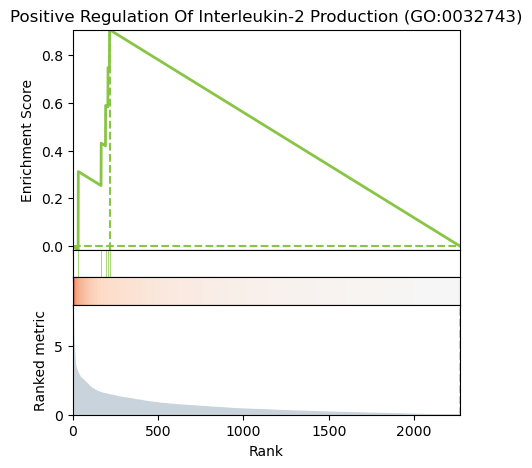

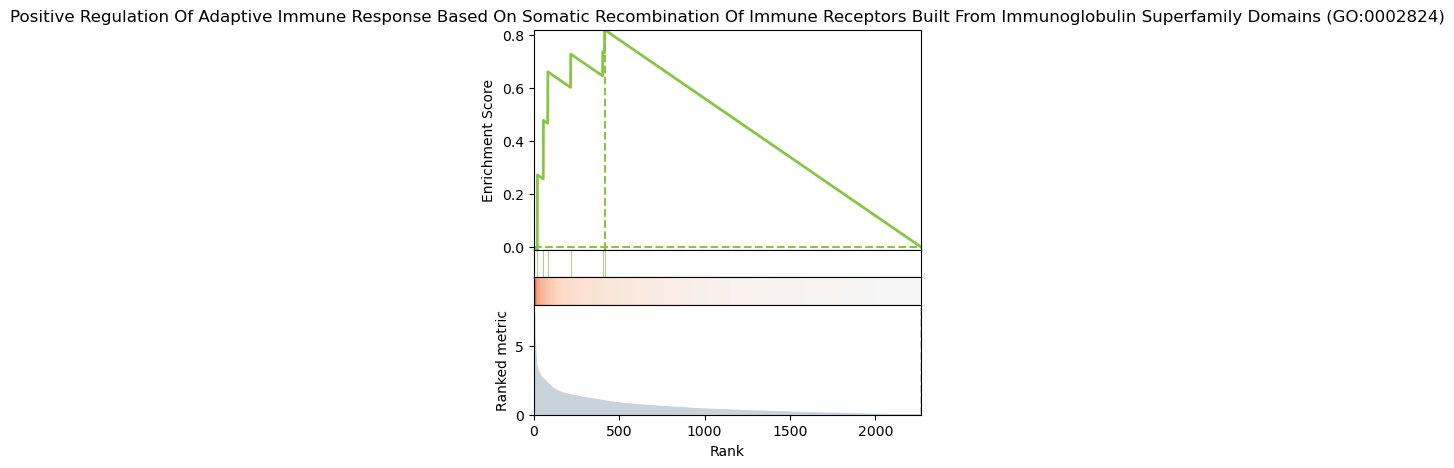

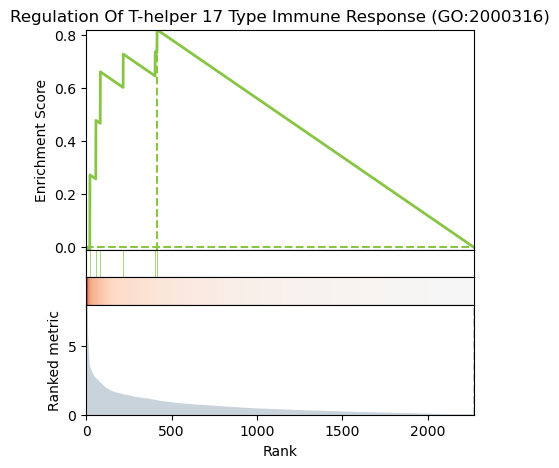

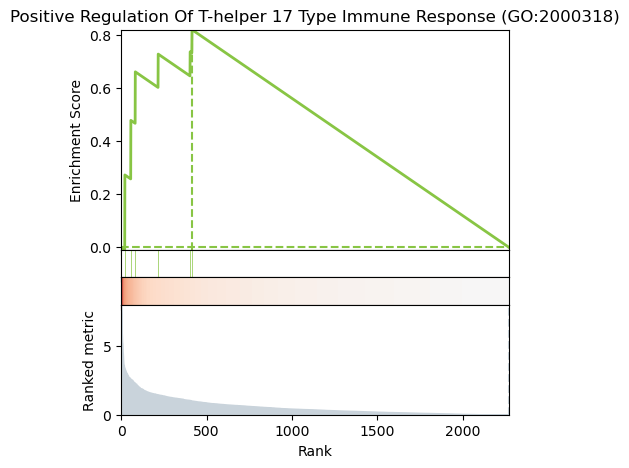

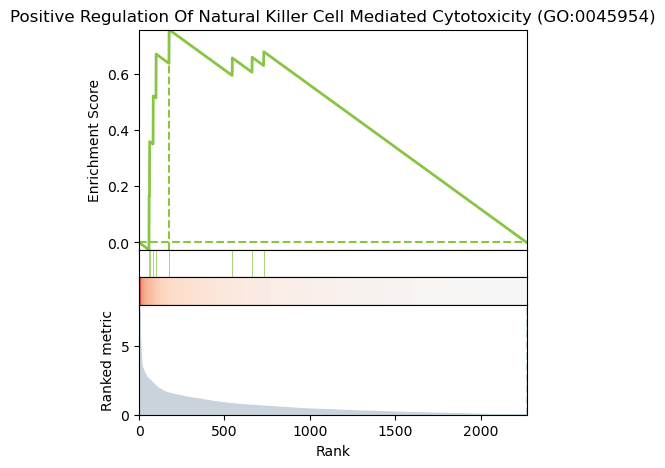

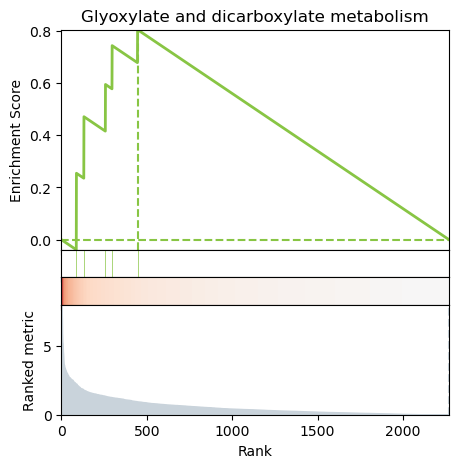

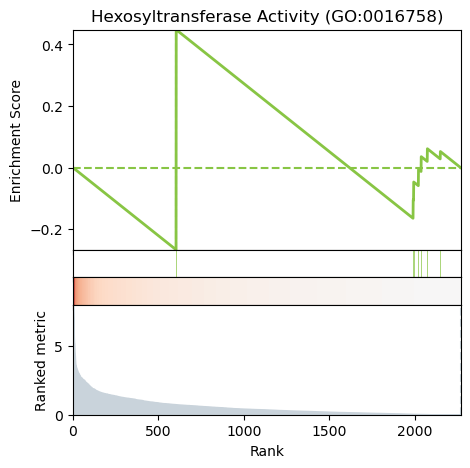

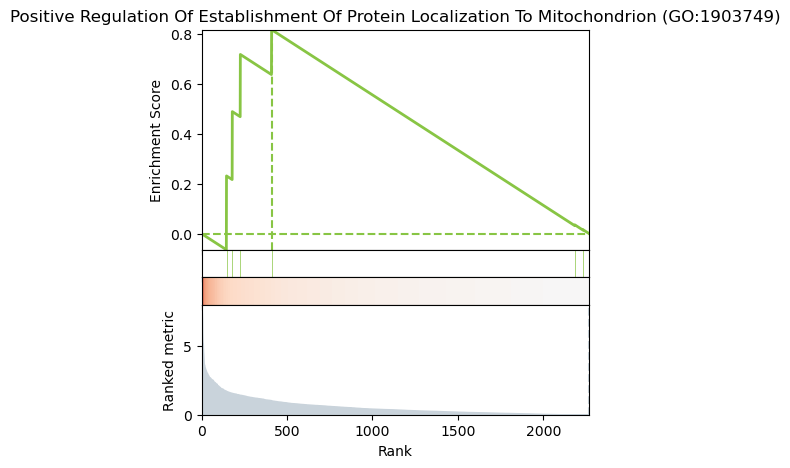

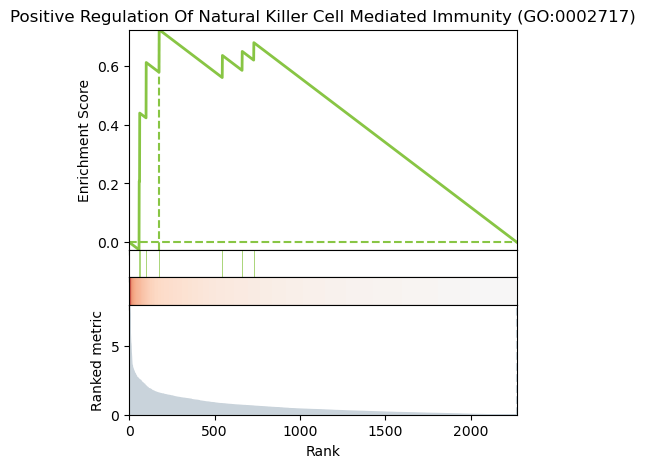

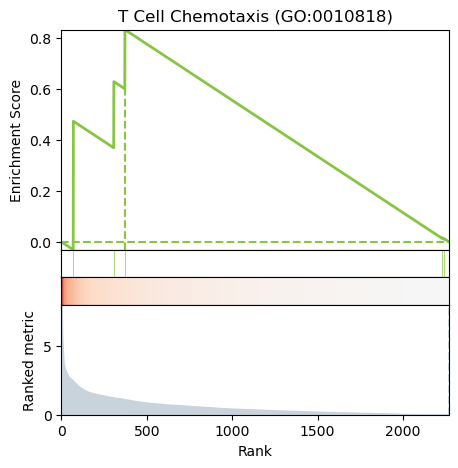

In [100]:
for x in MM_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)["Term"].tolist()[:10]:
    dc.plot_running_score(
        df=MM_gsea,
        stat='-LogP',
        net=decoupler_frame,
        source='source',
        target='target',
        set_name=x
    )

In [101]:
MMGene_series=MM_gsea[["Beta"]].T.rename(index={'Beta': 'Systemic'})
MMGene_series

Protein,AAAS,AAGAB,AARSD1,ABCC6,ABCC8,ABCF2,ABHD14B,ABI3BP,ABL1,ABO,...,ZNF75A,ZNF830,ZNF831,ZNF839,ZNRD2,ZNRF4,ZP3,ZPR1,ZRANB1,ZSWIM3
Systemic,-0.12404,0.086447,0.046508,0.122136,0.015087,0.052075,0.096899,0.016167,0.083707,-0.015585,...,0.056786,0.159015,0.03557,0.152527,0.023053,-0.240185,0.11126,0.025522,0.341852,0.020944


In [102]:
MMPathway_series=MM_Filtered_Pathways.set_index("Term")[["NES"]].T.rename(index={'NES': 'Systemic'})
MMPathway_series

Term,B Cell Mediated Immunity (GO:0019724),Cellular Response To Molecule Of Bacterial Origin (GO:0071219),Glyoxylate and dicarboxylate metabolism,Hexosyltransferase Activity (GO:0016758),Positive Regulation Of Adaptive Immune Response Based On Somatic Recombination Of Immune Receptors Built From Immunoglobulin Superfamily Domains (GO:0002824),Positive Regulation Of Establishment Of Protein Localization To Mitochondrion (GO:1903749),Positive Regulation Of Immune System Process (GO:0002684),Positive Regulation Of Interleukin-2 Production (GO:0032743),Positive Regulation Of Natural Killer Cell Mediated Cytotoxicity (GO:0045954),Positive Regulation Of Natural Killer Cell Mediated Immunity (GO:0002717),Positive Regulation Of T-helper 17 Type Immune Response (GO:2000318),Regulation Of Interleukin-2 Production (GO:0032663),Regulation Of Protein Targeting To Mitochondrion (GO:1903214),Regulation Of T-helper 17 Type Immune Response (GO:2000316),SH2 Domain Binding (GO:0042169),T Cell Chemotaxis (GO:0010818),Tryptophan metabolism
Systemic,-1.692383,1.549348,-1.889796,1.817507,-2.037502,1.808975,-1.581969,-2.08246,-2.034514,-1.789534,-2.037502,-1.460865,1.731535,-2.037502,-1.683487,1.777789,-1.658187


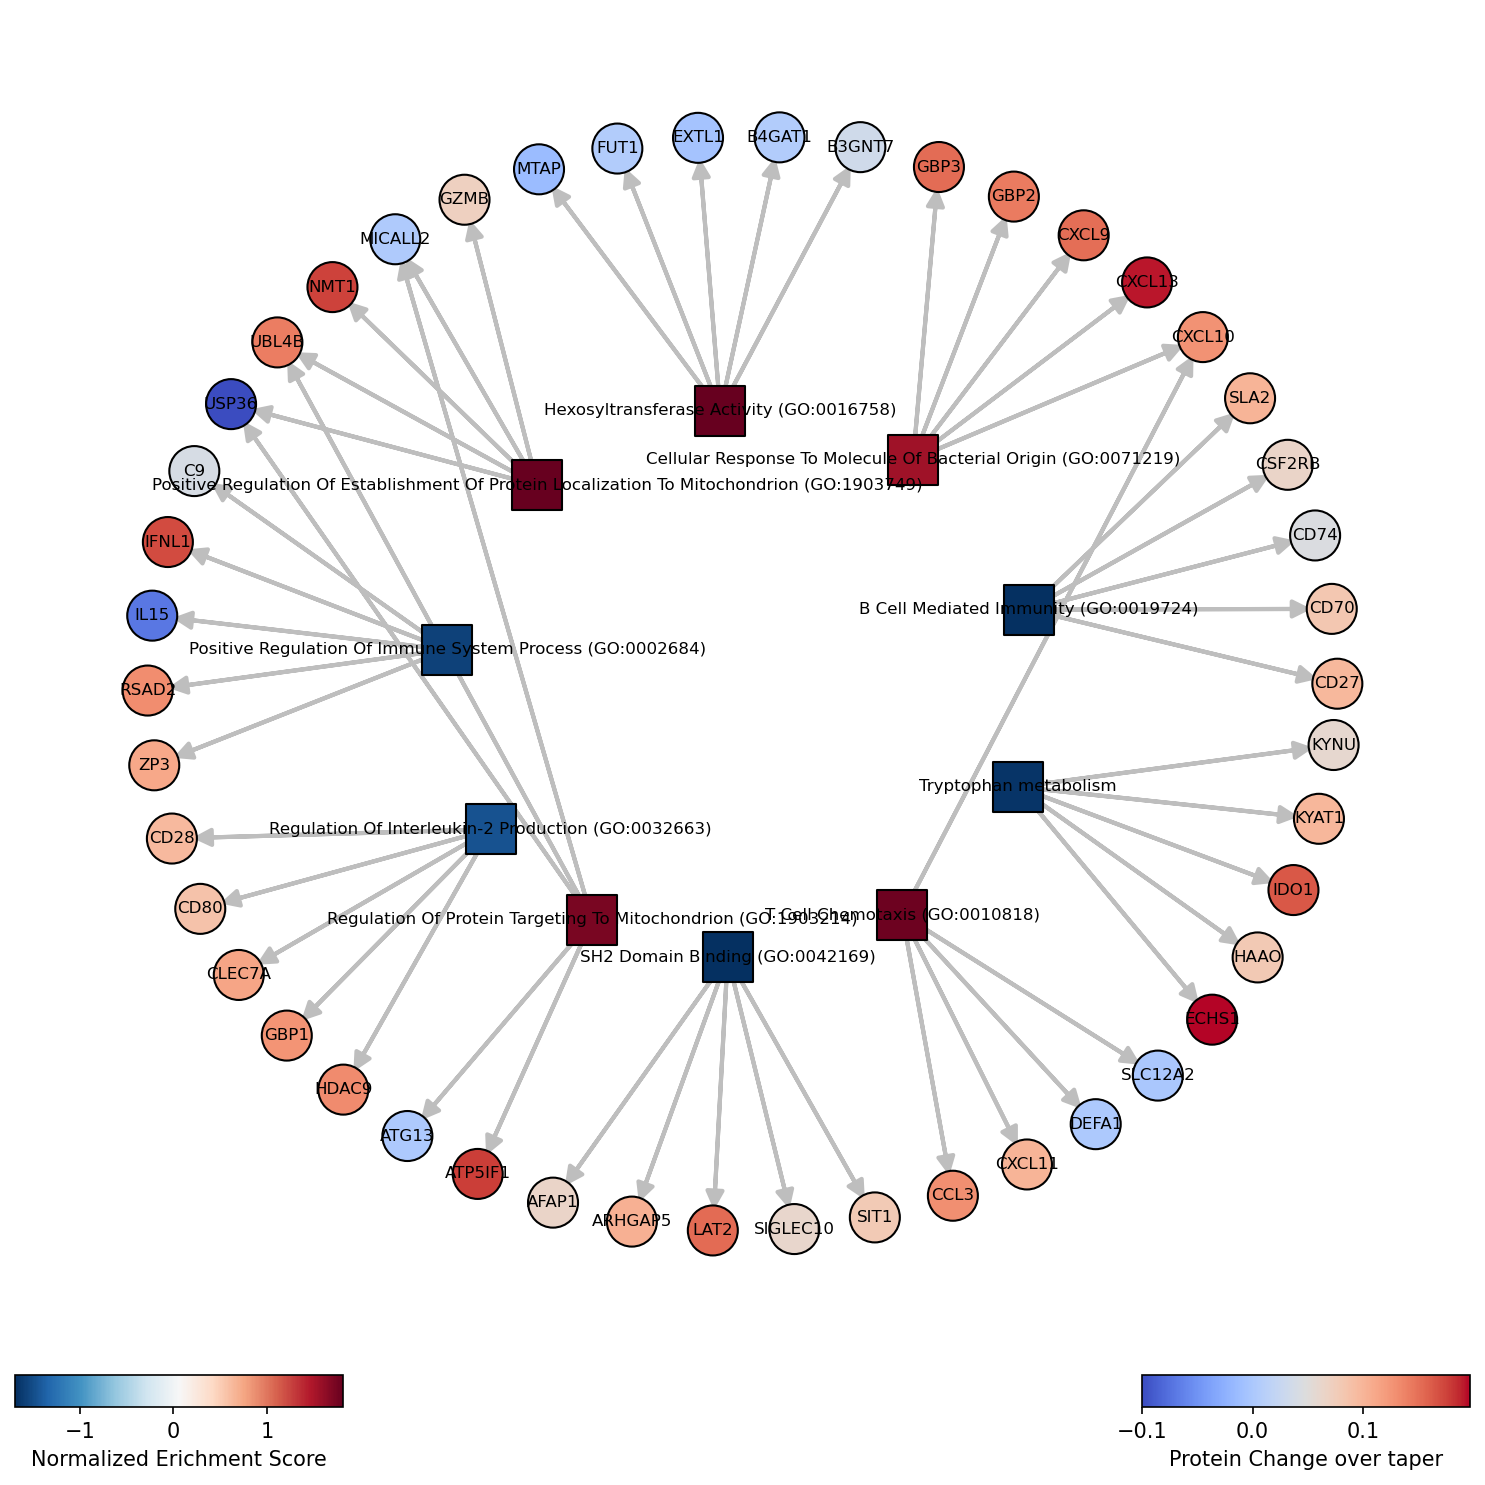

In [103]:
dc.plot_network(
    net=filtered_decoupler_frame,
    obs=MMGene_series,
    act=MMPathway_series,
    n_sources=MM_Filtered_Pathways.sort_values(by="NES", ascending=False)["Term"].tolist()[:10],
    n_targets=5,
    node_size=50,
    # s_cmap='Reds',
    t_cmap='coolwarm',
    c_pos_w='gray',
    c_neg_w='gray',
    figsize=(10, 10),
    label_size=8,
    layout="rt_circular",
    s_label="Normalized Erichment Score",
    t_label="Protein Change over taper",
    save="Mild_Moderate_Flarers_Network.png"
)

#### Severe Flare  GSEA

In [104]:
SS_gsea=Severe_Regression_outputs.set_index("Protein")
SS_gsea["-LogP"]=-np.log10(SS_gsea["P-Value"])
SS_gsea

,P-Value,Beta,Ranking,-LogP
Protein,,,,
A1BG,0.741855,-0.009460,-0.001227,0.129681
AAAS,0.027416,0.281871,0.440281,1.561992
AAGAB,0.112477,0.195324,0.185350,0.948937
AAMDC,0.331830,0.055185,0.026438,0.479084
AARSD1,0.275912,0.184431,0.103139,0.559230
...,...,...,...,...
ZSCAN21,0.717582,0.099537,0.014346,0.144129
ZSWIM3,0.560295,0.055812,0.014041,0.251584
ZSWIM8,0.170399,-0.157540,-0.121075,0.768533


In [105]:
filtered_decoupler_frame=decoupler_frame[decoupler_frame["target"].isin(set(SS_gsea.index))]
filtered_decoupler_frame

,source,target,Library
11,'De Novo' Post-Translational Protein Folding (...,ENTPD5,GO_Biological_Process_2023
17,'De Novo' Post-Translational Protein Folding (...,DNAJB13,GO_Biological_Process_2023
18,'De Novo' Post-Translational Protein Folding (...,HSPA2,GO_Biological_Process_2023
19,'De Novo' Post-Translational Protein Folding (...,DNAJB14,GO_Biological_Process_2023
22,'De Novo' Post-Translational Protein Folding (...,GAK,GO_Biological_Process_2023
...,...,...,...
302698,Zinc Ion Binding (GO:0008270),SMPDL3B,GO_Molecular_Function_2023
302712,Zinc Ion Binding (GO:0008270),ADAMTS4,GO_Molecular_Function_2023
302718,Zinc Ion Binding (GO:0008270),TRIM24,GO_Molecular_Function_2023
302730,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A14,GO_Molecular_Function_2023


In [106]:
SF_Pathways=dc.get_gsea_df(df=SS_gsea,stat="-LogP", net=filtered_decoupler_frame,source="source",target="target")

In [107]:
SF_Pathways.sort_values(by="FDR p-value").head(15)

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
793,Extracellular Structure Organization (GO:0043062),0.615692,1.467063,0.000000,0.000000,40,0.300000,0.075693,MATN3;CCDC80;MATN2;COL9A1;COL24A1;RECK;ADAMTS8...
788,External Encapsulating Structure Organization ...,0.620704,1.477202,0.000000,0.000000,39,0.307692,0.075693,MATN3;CCDC80;MATN2;COL9A1;COL24A1;RECK;ADAMTS8...
1287,Meiosis I (GO:0007127),0.819907,1.688164,0.000000,0.000000,10,0.500000,0.116468,FOXJ3;BRME1;MEIOC;DDX4;PTTG1
3905,miRNA Regulation of DNA Damage Response WP1530,-0.327902,-1.340425,0.000000,0.000000,20,1.000000,0.673800,CCND1;FAS;TP53;ABL1;CCNE1;RRM2B;GADD45B;CASP9;...
531,Cyclin-Dependent Protein Kinase Holoenzyme Com...,-0.731273,-1.948002,0.000000,0.000000,7,1.000000,0.270106,CCND1;CCNE1;CDKN1A;CDK14;CCND2;CDK12;CCNL2
3105,Regulation Of Microtubule Polymerization (GO:0...,-0.454710,-1.591891,0.000000,0.000000,12,1.000000,0.546745,TOGARAM1;DCTN1;MAP2;MET;CDH5;OCLN;SNCA;CAMSAP1...
571,DNA Damage Response WP707,-0.327902,-1.340425,0.000000,0.000000,20,1.000000,0.673800,CCND1;FAS;TP53;ABL1;CCNE1;RRM2B;GADD45B;CASP9;...
3063,Regulation Of Kinase Activity (GO:0043549),0.595302,1.432144,0.001000,0.351368,42,0.309524,0.127731,CCNYL2;TTN;DDR1;TYRO3;RET;ROR1;NTRK2;MST1R;CSR...
1816,Neuron Projection Guidance (GO:0097485),0.575475,1.400511,0.001000,0.351368,54,0.481481,0.265826,EPHA4;SEMA3F;PALLD;TNR;RET;NELL2;NRXN1;DRAXIN;...
1278,Mast Cell Mediated Immunity (GO:0002448),0.901916,1.632833,0.001159,0.351368,5,0.800000,0.079297,KIT;GRP;MILR1;S100A13


In [108]:
SF_Filtered_Pathways=SF_Pathways[SF_Pathways["FDR p-value"]<.25]
SF_Filtered_Pathways["Absolute_NES"]=np.absolute(SF_Filtered_Pathways["NES"])
SF_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)

/tmp/ipykernel_257/114924953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SF_Filtered_Pathways["Absolute_NES"]=np.absolute(SF_Filtered_Pathways["NES"])


,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge,Absolute_NES
531,Cyclin-Dependent Protein Kinase Holoenzyme Com...,-0.731273,-1.948002,0.0,0.0,7,1.000000,0.270106,CCND1;CCNE1;CDKN1A;CDK14;CCND2;CDK12;CCNL2,1.948002
1287,Meiosis I (GO:0007127),0.819907,1.688164,0.0,0.0,10,0.500000,0.116468,FOXJ3;BRME1;MEIOC;DDX4;PTTG1,1.688164
3105,Regulation Of Microtubule Polymerization (GO:0...,-0.454710,-1.591891,0.0,0.0,12,1.000000,0.546745,TOGARAM1;DCTN1;MAP2;MET;CDH5;OCLN;SNCA;CAMSAP1...,1.591891
788,External Encapsulating Structure Organization ...,0.620704,1.477202,0.0,0.0,39,0.307692,0.075693,MATN3;CCDC80;MATN2;COL9A1;COL24A1;RECK;ADAMTS8...,1.477202
793,Extracellular Structure Organization (GO:0043062),0.615692,1.467063,0.0,0.0,40,0.300000,0.075693,MATN3;CCDC80;MATN2;COL9A1;COL24A1;RECK;ADAMTS8...,1.467063
571,DNA Damage Response WP707,-0.327902,-1.340425,0.0,0.0,20,1.000000,0.673800,CCND1;FAS;TP53;ABL1;CCNE1;RRM2B;GADD45B;CASP9;...,1.340425
3905,miRNA Regulation of DNA Damage Response WP1530,-0.327902,-1.340425,0.0,0.0,20,1.000000,0.673800,CCND1;FAS;TP53;ABL1;CCNE1;RRM2B;GADD45B;CASP9;...,1.340425


In [109]:
SF_Pathways.to_csv("SF_GSEA_P_Rank.csv")

##### Plotting GSEA results

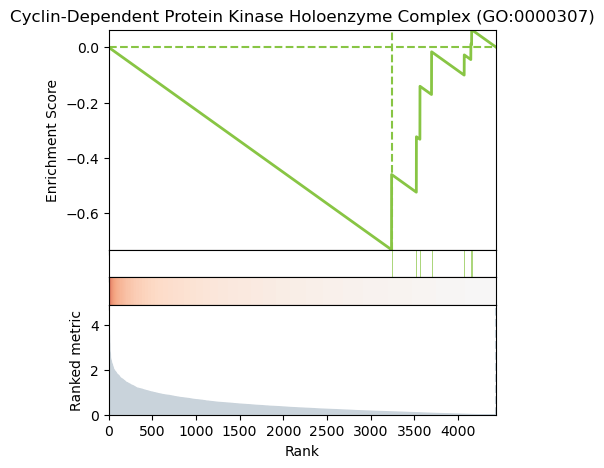

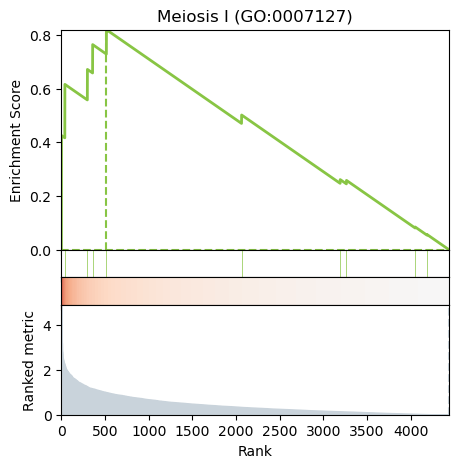

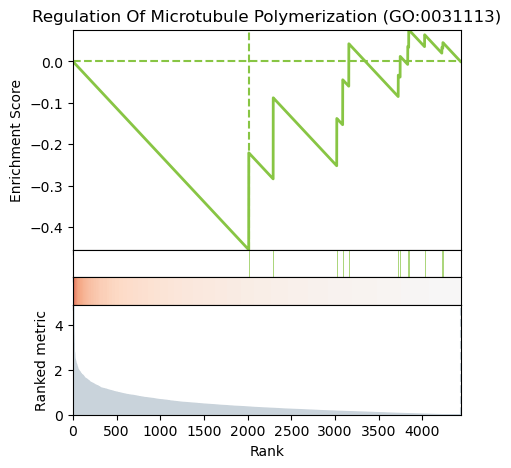

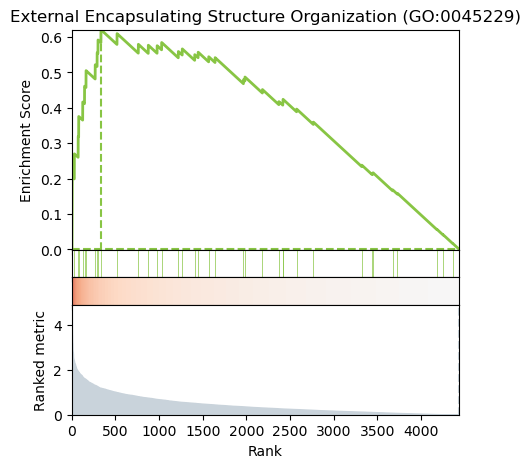

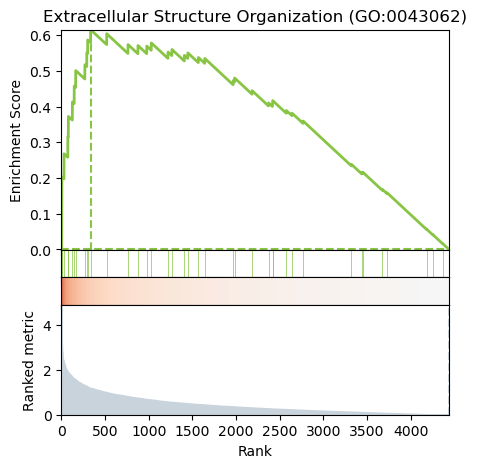

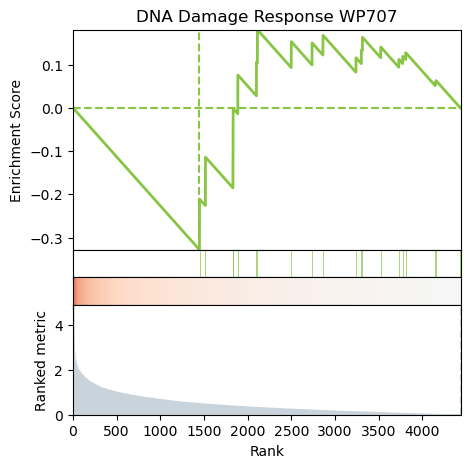

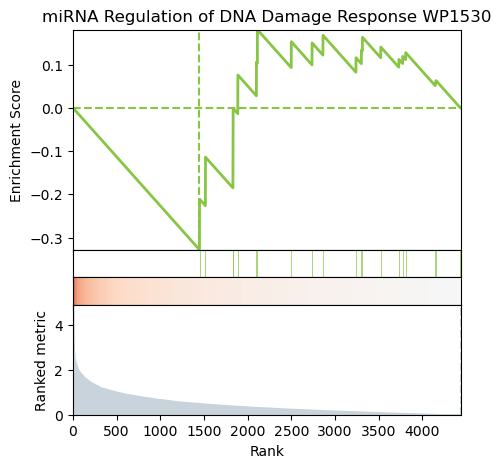

In [110]:
for x in SF_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)["Term"].tolist()[:10]:
    dc.plot_running_score(
        df=SS_gsea,
        stat='-LogP',
        net=decoupler_frame,
        source='source',
        target='target',
        set_name=x
    )

In [111]:
SFGene_series=SS_gsea[["Beta"]].T.rename(index={'Beta': 'Systemic'})
SFGene_series

Protein,A1BG,AAAS,AAGAB,AAMDC,AARSD1,AASDH,ABCA2,ABCB5,ABCC6,ABCC8,...,ZNRF4,ZP3,ZPR1,ZRANB1,ZRSR2,ZSCAN21,ZSWIM3,ZSWIM8,ZUP1,ZWILCH
Systemic,-0.00946,0.281871,0.195324,0.055185,0.184431,0.124902,-0.180182,0.11217,0.136405,0.251525,...,0.24084,0.424557,0.057373,0.015097,0.1073,0.099537,0.055812,-0.15754,-0.09654,0.115437


In [112]:
SFPathway_series=SF_Filtered_Pathways.set_index("Term")[["NES"]].T.rename(index={'NES': 'Systemic'})
SFPathway_series

Term,Cyclin-Dependent Protein Kinase Holoenzyme Complex (GO:0000307),DNA Damage Response WP707,External Encapsulating Structure Organization (GO:0045229),Extracellular Structure Organization (GO:0043062),Meiosis I (GO:0007127),Regulation Of Microtubule Polymerization (GO:0031113),miRNA Regulation of DNA Damage Response WP1530
Systemic,-1.948002,-1.340425,1.477202,1.467063,1.688164,-1.591891,-1.340425


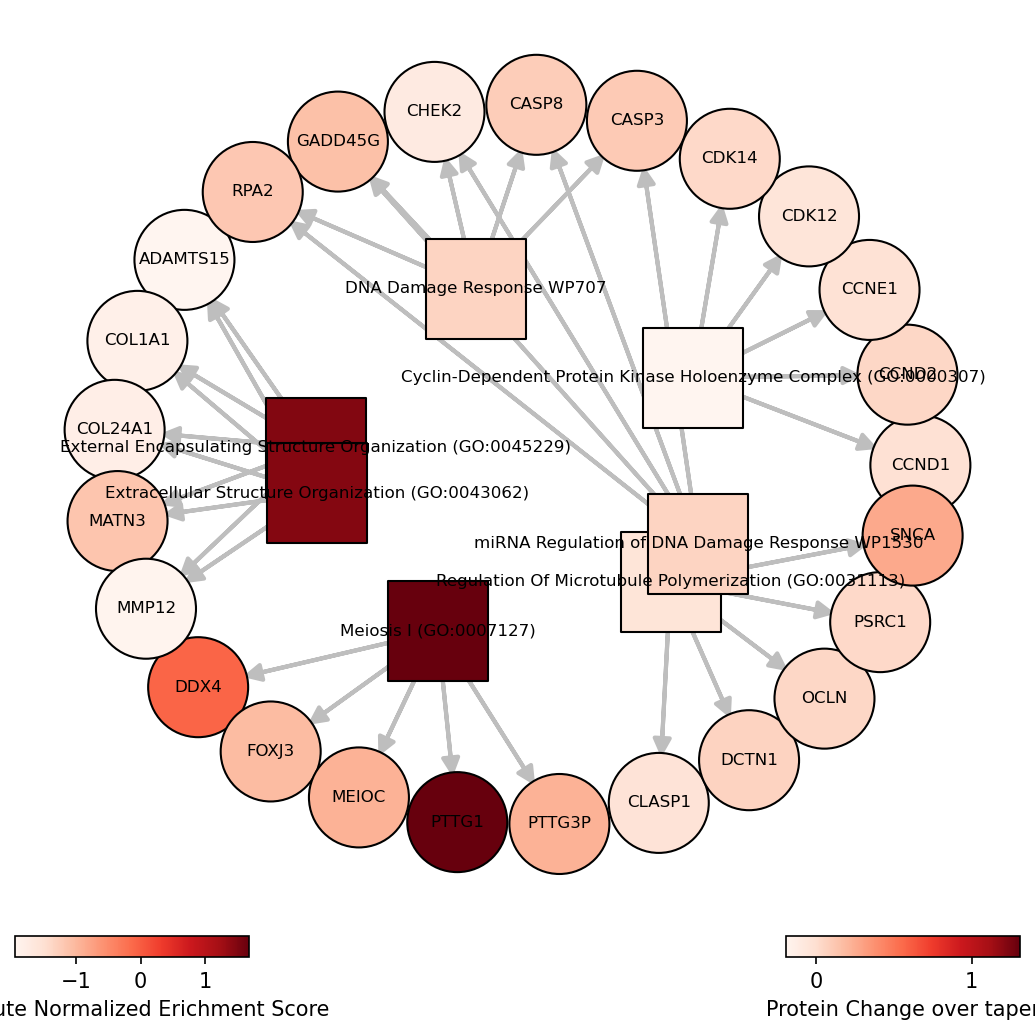

In [113]:
dc.plot_network(
    net=filtered_decoupler_frame,
    obs=SFGene_series,
    act=SFPathway_series,
    n_sources=SF_Filtered_Pathways.sort_values(by="NES", ascending=False)["Term"].tolist()[:10],
    n_targets=5,
    node_size=100,
    s_cmap='Reds',
    t_cmap='Reds',
    c_pos_w='gray',
    c_neg_w='gray',
    figsize=(7, 7),
    label_size=8,
    layout="rt_circular",
    s_label="Absolute Normalized Erichment Score",
    t_label="Protein Change over taper",
    save="Severe_Flarers_Network.png"
)

#### Perform GSEA on proteins increased in Severe Flarers with respect to Mild-Moderate Flarers

In [165]:
Comparison_Frame=Comparison_Frame.set_index("Protein")
Comparison_Frame["-LogP"]=-np.log10(Comparison_Frame["P-Value"])
Comparison_Frame

,P-Value,Beta,-LogP
Protein,,,
AAAS,0.001424,0.450543,2.846434
ABCC6,0.883153,-0.016881,0.053964
ABCC8,0.158282,0.170557,0.800569
ABCF2,0.343760,-0.089944,0.463744
ABCF3,0.987256,-0.001064,0.005570
...,...,...,...
ZP3,0.316629,0.247673,0.499449
ZPR1,0.737330,-0.035718,0.132338
ZRSR2,0.879195,-0.028453,0.055915


In [166]:
filtered_decoupler_frame=decoupler_frame[decoupler_frame["target"].isin(set(Comparison_Frame.index))]
filtered_decoupler_frame

,source,target,Library
11,'De Novo' Post-Translational Protein Folding (...,ENTPD5,GO_Biological_Process_2023
19,'De Novo' Post-Translational Protein Folding (...,DNAJB14,GO_Biological_Process_2023
26,'De Novo' Post-Translational Protein Folding (...,ST13P5,GO_Biological_Process_2023
31,'De Novo' Post-Translational Protein Folding (...,HSPA13,GO_Biological_Process_2023
37,'De Novo' Post-Translational Protein Folding (...,UGGT1,GO_Biological_Process_2023
...,...,...,...
302692,Zinc Ion Binding (GO:0008270),PLA2G15,GO_Molecular_Function_2023
302696,Zinc Ion Binding (GO:0008270),SMPDL3A,GO_Molecular_Function_2023
302698,Zinc Ion Binding (GO:0008270),SMPDL3B,GO_Molecular_Function_2023
302730,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A14,GO_Molecular_Function_2023


In [167]:
Comp_Pathways=dc.get_gsea_df(df=Comparison_Frame,stat="P-Value", net=filtered_decoupler_frame,source="source",target="target")

In [168]:
Comp_Pathways=dc.get_gsea_df(df=Comparison_Frame,stat="Beta", net=filtered_decoupler_frame,source="source",target="target")

In [169]:
Comp_Pathways

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,'De Novo' Post-Translational Protein Folding (...,0.480621,0.982495,0.468031,0.884224,5,0.200000,0.007819,ST13P5
1,3'-5' Exonuclease Activity (GO:0008408),0.437806,0.986343,0.457534,0.882328,7,0.142857,0.017284,ERI2
2,3'-5'-RNA Exonuclease Activity (GO:0000175),0.475213,1.014369,0.438356,0.879584,6,0.166667,0.017284,ERI2
3,9+2 Motile Cilium (GO:0097729),0.503007,1.453517,0.074324,0.645150,16,0.312500,0.117695,KIF9;DNAH9;TEKT3;DNAH17;CFAP74
4,AGE-RAGE signaling pathway in diabetic complic...,-0.477011,-1.317099,0.129707,0.710620,23,0.695652,0.441975,VCAM1;MAPK9;THBD;VEGFD;NOS3;COL1A1;VEGFB;COL4A...
...,...,...,...,...,...,...,...,...,...
2433,rRNA Metabolic Process (GO:0016072),-0.632507,-1.525685,0.026432,0.514109,13,0.230769,0.015638,BYSL;RRP7BP;DDX10
2434,rRNA Processing (GO:0006364),-0.560229,-1.352527,0.101471,0.700808,13,0.153846,0.015638,RRP7BP;DDX10
2435,tRNA Modification (GO:0006400),0.537470,1.097317,0.367347,0.846059,5,0.600000,0.095885,DUS2;TRMT9B;GTPBP3
2436,trans-Golgi Network (GO:0005802),-0.371434,-1.068505,0.383508,0.856636,29,0.206897,0.153086,TBC1D23;VPS54;SCAMP2;KIF13A;PLEKHA8P1;STX8


In [170]:
Comp_Pathways[Comp_Pathways["FDR p-value"]<.25].sort_values(by="FDR p-value")

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
1128,Neural Crest Differentiation WP2064,-0.744419,-1.852590,0.000000,0.000000,14,0.357143,0.103292,DLL4;LHX2;TFAP2A;COL2A1;HDAC9
2194,Shigellosis,-0.655693,-1.843427,0.000000,0.000000,27,0.370370,0.133333,ARHGEF2;CASP1;CASP4;SEPTIN7;IFNB1;PRKCQ;MAPK12...
1167,Notch signaling pathway,-0.820378,-1.744125,0.000000,0.000000,8,0.500000,0.118519,DLL4;DTX2;NUMB;DTX3L
1166,Notch Signaling WP268,-0.820378,-1.744125,0.000000,0.000000,8,0.500000,0.118519,DLL4;DTX2;NUMB;DTX3L
567,Fluid shear stress and atherosclerosis,-0.625809,-1.765414,0.000000,0.000000,27,0.259259,0.109877,GSTA3;ARHGEF2;GSTT2B;GSTM4;MAPK12;GSTA1;ASS1
553,Fatty acid degradation,-0.819496,-1.774893,0.000000,0.000000,9,1.000000,0.183951,ALDH2;ADH1B;ADH4;ECHS1;ACAA1;ACADSB;ECI2;ACSL1...
2354,Ubiquitin-Dependent ERAD Pathway (GO:0030433),-0.808035,-1.803001,0.000000,0.000000,10,0.400000,0.083128,RNF5;EDEM2;FAF2;NCCRP1
302,Chloride Transport (GO:0006821),0.932371,1.918655,0.000000,0.000000,5,1.000000,0.069547,APOL1;GABRA4;CLIC5;CLIC3;CLIC1
406,Defense Response To Symbiont (GO:0140546),-0.618393,-1.750607,0.001366,0.188379,28,0.535714,0.217284,RIGI;CASP1;EIF2AK2;IFNL1;RAB2B;TLR3;IFNB1;DDX6...
323,Cilium Organization (GO:0044782),-0.590107,-1.751353,0.001307,0.188379,34,0.352941,0.106173,EHD4;SCLT1;TSGA10IP;CEP20;SEPTIN7;AHI1;PKD2;CE...


In [171]:
decoupler_frame

,source,target,Library
0,'De Novo' AMP Biosynthetic Process (GO:0044208),ATIC,GO_Biological_Process_2023
1,'De Novo' AMP Biosynthetic Process (GO:0044208),PAICS,GO_Biological_Process_2023
2,'De Novo' AMP Biosynthetic Process (GO:0044208),PFAS,GO_Biological_Process_2023
3,'De Novo' AMP Biosynthetic Process (GO:0044208),ADSS1,GO_Biological_Process_2023
4,'De Novo' AMP Biosynthetic Process (GO:0044208),ADSS2,GO_Biological_Process_2023
...,...,...,...
302737,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A8,GO_Molecular_Function_2023
302738,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A3,GO_Molecular_Function_2023
302739,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A2,GO_Molecular_Function_2023
302740,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A5,GO_Molecular_Function_2023


In [172]:
decoupler_frame[((decoupler_frame["source"]=="Notch signaling pathway")|(decoupler_frame["source"]=="Notch Signaling WP268"))]

,source,target,Library
187633,Notch Signaling WP268,KCNJ5,WikiPathways_2019_Human
187634,Notch Signaling WP268,CREBBP,WikiPathways_2019_Human
187635,Notch Signaling WP268,JAG1,WikiPathways_2019_Human
187636,Notch Signaling WP268,JAG2,WikiPathways_2019_Human
187637,Notch Signaling WP268,PTCRA,WikiPathways_2019_Human
...,...,...,...
214896,Notch signaling pathway,RBPJ,KEGG_2021_Human
214897,Notch signaling pathway,LFNG,KEGG_2021_Human
214898,Notch signaling pathway,HEY2,KEGG_2021_Human
214899,Notch signaling pathway,HEY1,KEGG_2021_Human


In [173]:
Comp_Pathways.to_csv("Comp_GSEA_Beta_Rank.csv")

In [174]:
Comp_Filtered_Pathways=Comp_Pathways[Comp_Pathways["FDR p-value"]<.25]
Comp_Filtered_Pathways["Absolute_NES"]=np.absolute(Comp_Filtered_Pathways["NES"])
Comp_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)

/tmp/ipykernel_257/106095398.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Comp_Filtered_Pathways["Absolute_NES"]=np.absolute(Comp_Filtered_Pathways["NES"])


,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge,Absolute_NES
302,Chloride Transport (GO:0006821),0.932371,1.918655,0.000000,0.000000,5,1.000000,0.069547,APOL1;GABRA4;CLIC5;CLIC3;CLIC1,1.918655
1128,Neural Crest Differentiation WP2064,-0.744419,-1.852590,0.000000,0.000000,14,0.357143,0.103292,DLL4;LHX2;TFAP2A;COL2A1;HDAC9,1.852590
2194,Shigellosis,-0.655693,-1.843427,0.000000,0.000000,27,0.370370,0.133333,ARHGEF2;CASP1;CASP4;SEPTIN7;IFNB1;PRKCQ;MAPK12...,1.843427
294,Chemical carcinogenesis,-0.706373,-1.841132,0.001391,0.188379,20,0.350000,0.104115,GSTA3;GSTT2B;DLL4;FGF5;GSTM4;GSTA1;HRAS,1.841132
2354,Ubiquitin-Dependent ERAD Pathway (GO:0030433),-0.808035,-1.803001,0.000000,0.000000,10,0.400000,0.083128,RNF5;EDEM2;FAF2;NCCRP1,1.803001
553,Fatty acid degradation,-0.819496,-1.774893,0.000000,0.000000,9,1.000000,0.183951,ALDH2;ADH1B;ADH4;ECHS1;ACAA1;ACADSB;ECI2;ACSL1...,1.774893
567,Fluid shear stress and atherosclerosis,-0.625809,-1.765414,0.000000,0.000000,27,0.259259,0.109877,GSTA3;ARHGEF2;GSTT2B;GSTM4;MAPK12;GSTA1;ASS1,1.765414
407,Defense Response To Virus (GO:0051607),-0.602569,-1.754827,0.001318,0.188379,33,0.545455,0.217284,RIGI;CASP1;EIF2AK2;RNF135;IFNL1;RAB2B;CXCL10;T...,1.754827
323,Cilium Organization (GO:0044782),-0.590107,-1.751353,0.001307,0.188379,34,0.352941,0.106173,EHD4;SCLT1;TSGA10IP;CEP20;SEPTIN7;AHI1;PKD2;CE...,1.751353
406,Defense Response To Symbiont (GO:0140546),-0.618393,-1.750607,0.001366,0.188379,28,0.535714,0.217284,RIGI;CASP1;EIF2AK2;IFNL1;RAB2B;TLR3;IFNB1;DDX6...,1.750607


##### Plotting GSEA results

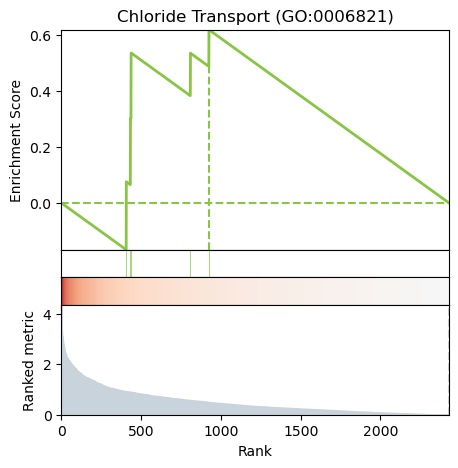

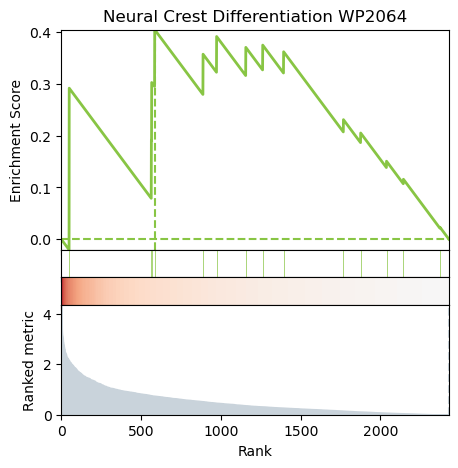

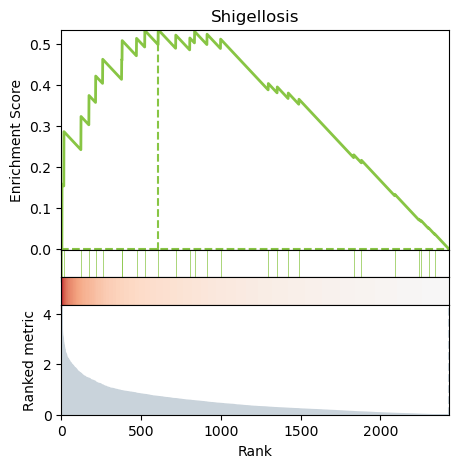

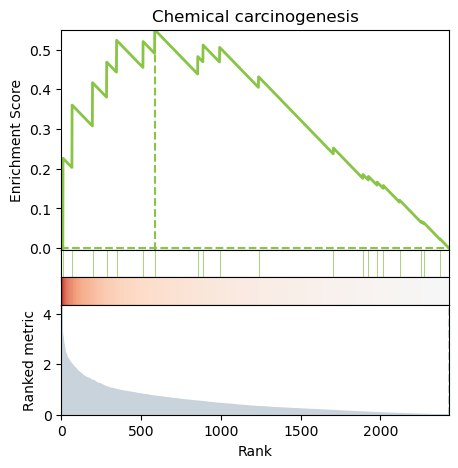

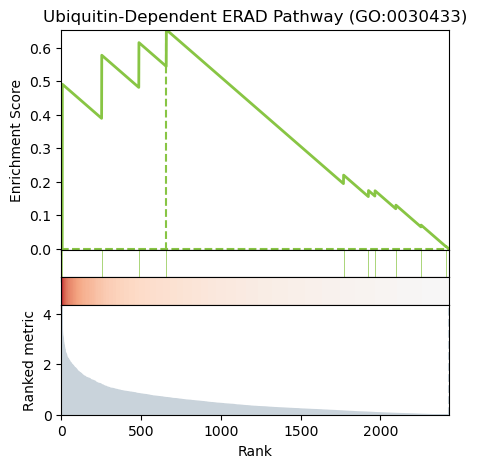

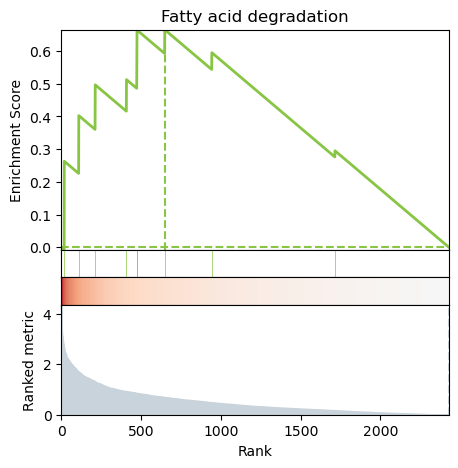

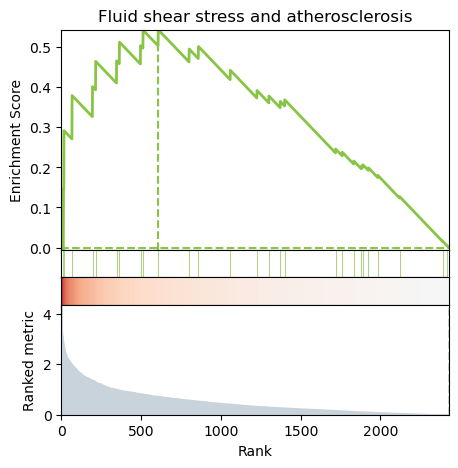

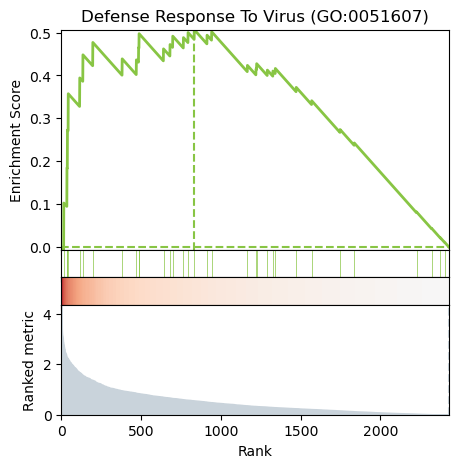

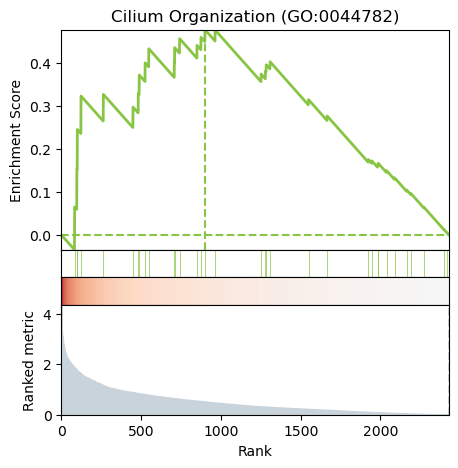

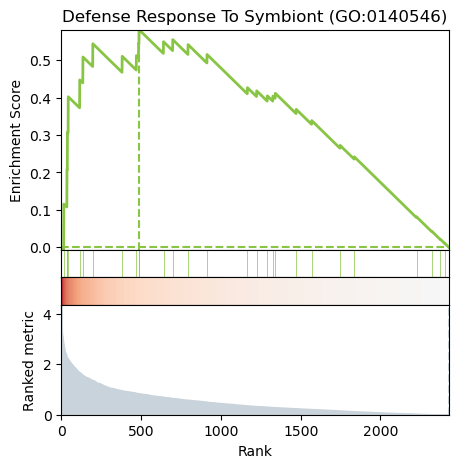

In [175]:
for x in Comp_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)["Term"].tolist()[:10]:
    dc.plot_running_score(
        df=Comparison_Frame,
        stat='-LogP',
        net=decoupler_frame,
        source='source',
        target='target',
        set_name=x
    )

In [176]:
Comp_Gene_series=Comparison_Frame[["Beta"]].T.rename(index={'Beta': 'Systemic'})
Comp_Gene_series

Protein,AAAS,ABCC6,ABCC8,ABCF2,ABCF3,ABHD14B,ABHD5,ABI3BP,ABL1,ABO,...,ZNF75A,ZNF831,ZNF839,ZNRD2,ZNRF4,ZP3,ZPR1,ZRSR2,ZSWIM3,ZUP1
Systemic,0.450543,-0.016881,0.170557,-0.089944,-0.001064,0.049567,0.013804,0.001072,-0.133296,0.058049,...,-0.032585,0.006204,-0.058448,-0.010226,-0.171132,0.247673,-0.035718,-0.028453,0.116911,-0.061214


In [177]:
Comp_Pathway_series=Comp_Filtered_Pathways.set_index("Term")[["NES"]].T.rename(index={'NES': 'Systemic'})
Comp_Pathway_series

Term,Cell adhesion molecules,Chemical carcinogenesis,Chloride Transport (GO:0006821),Cilium Organization (GO:0044782),Defense Response To Symbiont (GO:0140546),Defense Response To Virus (GO:0051607),Fatty acid degradation,Fluid shear stress and atherosclerosis,Heart Contraction (GO:0060047),Neural Crest Differentiation WP2064,Notch Signaling WP268,Notch signaling pathway,Pathogenic Escherichia coli infection,Positive Regulation Of Cytokine Production (GO:0001819),Positive Regulation Of Tumor Necrosis Factor Superfamily Cytokine Production (GO:1903557),Regulation Of Cell Population Proliferation (GO:0042127),Regulation Of Tumor Necrosis Factor Production (GO:0032680),Shigellosis,Thyroid hormone signaling pathway,Ubiquitin-Dependent ERAD Pathway (GO:0030433)
Systemic,-1.713729,-1.841132,1.918655,-1.751353,-1.750607,-1.754827,-1.774893,-1.765414,-1.702132,-1.85259,-1.744125,-1.744125,-1.690846,-1.706573,-1.725314,-1.535598,-1.739174,-1.843427,-1.627329,-1.803001


In [179]:
Comp_Pathways[Comp_Pathways["FDR p-value"]<.05].sort_values(by="FDR p-value")["Term"].tolist()

['Chloride Transport (GO:0006821)',
 'Fatty acid degradation',
 'Fluid shear stress and atherosclerosis',
 'Neural Crest Differentiation WP2064',
 'Notch Signaling WP268',
 'Notch signaling pathway',
 'Shigellosis',
 'Ubiquitin-Dependent ERAD Pathway (GO:0030433)']

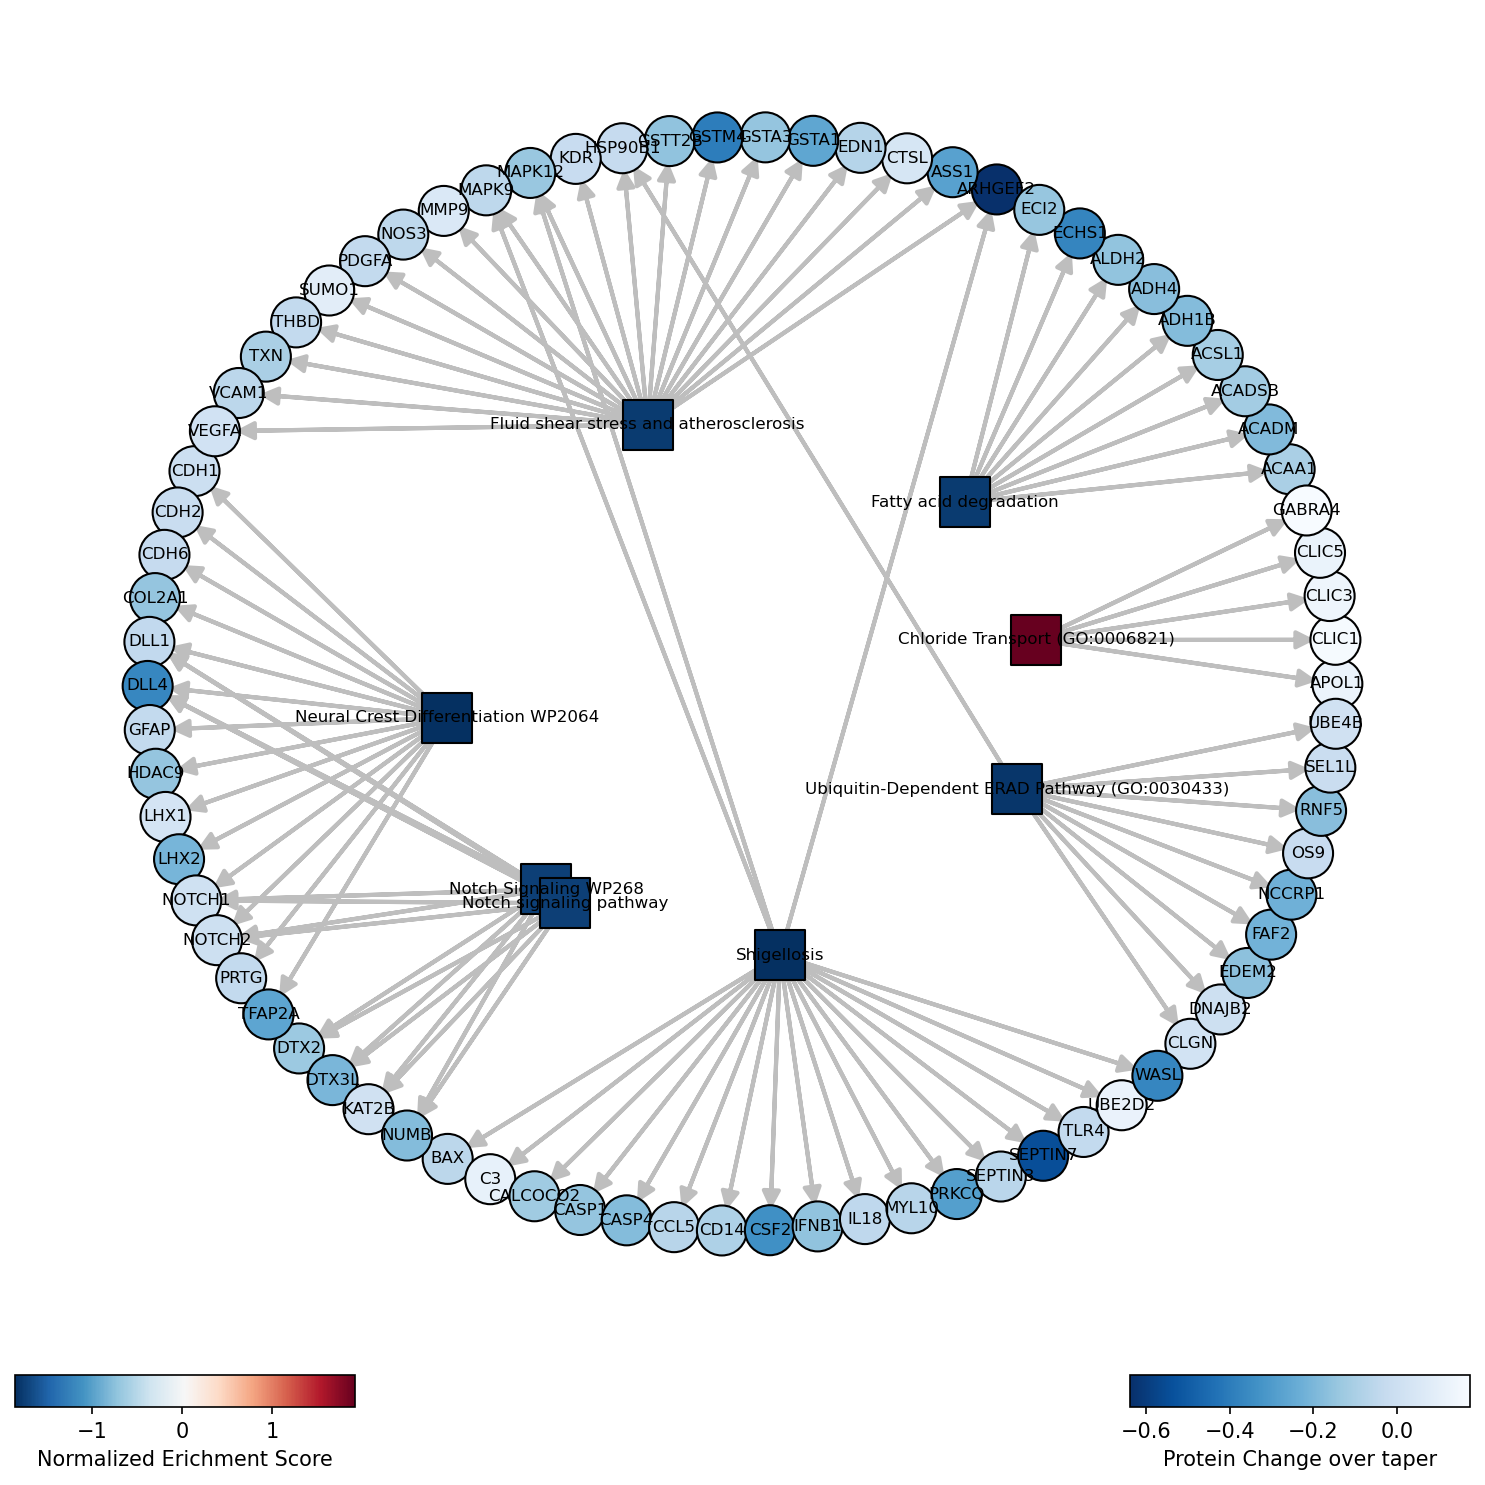

In [178]:
dc.plot_network(
    net=filtered_decoupler_frame,
    obs=Comp_Gene_series,
    act=Comp_Pathway_series,
    n_sources=Comp_Pathways[Comp_Pathways["FDR p-value"]<.05].sort_values(by="FDR p-value")["Term"].tolist(),
    n_targets=20,
    node_size=50,
    # s_cmap='Reds',
    t_cmap='Blues_r',
    c_pos_w='gray',
    c_neg_w='gray',
    figsize=(10, 10),
    label_size=8,
    layout="rt_circular",
    s_label="Normalized Erichment Score",
    t_label="Protein Change over taper",
    save="Severe_vs_Mild_Flarers_Network.png"
)

#### Perform GSEA on proteins increased in Flarers Overall

In [128]:
Overall_Regression_outputs=Overall_Regression_outputs.set_index("Protein")
Overall_Regression_outputs["-LogP"]=-np.log10(Overall_Regression_outputs["P-Value"])
Overall_Regression_outputs

,P-Value,Beta,-LogP
Protein,,,
AAAS,0.129757,-0.136352,0.886868
ABCC6,0.066941,0.130729,1.174305
ABCC8,0.660546,0.033261,0.180097
ABCF2,0.454334,0.044933,0.342624
ABCF3,0.382280,0.035739,0.417618
...,...,...,...
ZP3,0.356400,0.129364,0.448062
ZPR1,0.479789,0.044162,0.318950
ZRSR2,0.517201,0.082570,0.286341


In [129]:
filtered_decoupler_frame=decoupler_frame[decoupler_frame["target"].isin(set(Overall_Regression_outputs.index))]
filtered_decoupler_frame

,source,target,Library
11,'De Novo' Post-Translational Protein Folding (...,ENTPD5,GO_Biological_Process_2023
19,'De Novo' Post-Translational Protein Folding (...,DNAJB14,GO_Biological_Process_2023
26,'De Novo' Post-Translational Protein Folding (...,ST13P5,GO_Biological_Process_2023
31,'De Novo' Post-Translational Protein Folding (...,HSPA13,GO_Biological_Process_2023
37,'De Novo' Post-Translational Protein Folding (...,UGGT1,GO_Biological_Process_2023
...,...,...,...
302692,Zinc Ion Binding (GO:0008270),PLA2G15,GO_Molecular_Function_2023
302696,Zinc Ion Binding (GO:0008270),SMPDL3A,GO_Molecular_Function_2023
302698,Zinc Ion Binding (GO:0008270),SMPDL3B,GO_Molecular_Function_2023
302730,Zinc Ion Transmembrane Transporter Activity (G...,SLC39A14,GO_Molecular_Function_2023


In [130]:
Overall_Pathways=dc.get_gsea_df(df=Overall_Regression_outputs,stat="Beta", net=filtered_decoupler_frame,source="source",target="target")

In [131]:
Overall_Pathways

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,'De Novo' Post-Translational Protein Folding (...,0.428020,0.764130,0.811688,0.988041,5,0.600000,0.431276,HSPA13;DNAJB14;UGGT1
1,3'-5' Exonuclease Activity (GO:0008408),-0.410375,-1.036805,0.365482,0.868426,7,0.142857,0.003292,ERCC4
2,3'-5'-RNA Exonuclease Activity (GO:0000175),0.567126,1.057625,0.401042,0.888187,6,0.500000,0.216461,DIS3L;ERI1;EXOSC10
3,9+2 Motile Cilium (GO:0097729),0.580659,1.343104,0.074972,0.727876,16,0.500000,0.246914,KIF9;DNAH9;TEKT3;TPPP2;DCDC2C;CFAP74;DNAH5;DNALI1
4,AGE-RAGE signaling pathway in diabetic complic...,0.412339,1.008119,0.491304,0.905730,23,0.695652,0.529630,VCAM1;MAPK9;THBD;VEGFD;NOS3;VEGFB;COL4A1;BAX;P...
...,...,...,...,...,...,...,...,...,...
2433,rRNA Metabolic Process (GO:0016072),0.714852,1.561497,0.004499,0.434271,13,0.538462,0.200823,BYSL;DIS3L;RRP7BP;EMG1;EXOSC10;DDX10;PIN4
2434,rRNA Processing (GO:0006364),0.651823,1.407334,0.032658,0.727876,13,0.461538,0.216461,ERI1;RRP7BP;EMG1;EXOSC10;DDX10;PIN4
2435,tRNA Modification (GO:0006400),0.480022,0.868461,0.689258,0.963544,5,0.400000,0.219342,TYW5;SSB
2436,trans-Golgi Network (GO:0005802),0.464553,1.164140,0.247108,0.839067,29,0.206897,0.144444,TBC1D23;EIPR1;VPS54;SCAMP2;ATXN2;STX8


In [132]:
Overall_Pathways[Overall_Pathways["FDR p-value"]<.25].sort_values(by="FDR p-value")

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
341,Complement and Coagulation Cascades WP558,-0.464676,-1.684225,0.0,0.0,26,0.538462,0.227160,CFH;VWF;SERPINA5;CFB;CFD;F13B;CFI;SERPINC1;C3;...
342,Complement and coagulation cascades,-0.435781,-1.707669,0.0,0.0,34,0.529412,0.227160,CFH;VWF;CFHR5;CFHR2;SERPINA5;CFB;CFD;F13B;CFI;...
525,Exopeptidase Activity (GO:0008238),-0.571468,-1.926796,0.0,0.0,20,0.600000,0.233333,DPEP1;CPB1;PRCP;MME;LTA4H;XPNPEP2;ANPEP;FOLH1;...
743,Intracellular Non-Membrane-Bounded Organelle (...,0.501266,1.420636,0.0,0.0,132,0.500000,0.273663,CKAP5;ABL1;HIP1;ARHGEF2;NUDC;BYSL;RIPOR2;CASP1...
1191,Oligodendrocyte Differentiation (GO:0048709),-0.906883,-1.964341,0.0,0.0,5,0.400000,0.020988,SOX13;EIF2B5
1719,RNA Binding (GO:0003723),0.522325,1.466739,0.0,0.0,113,0.486726,0.249383,RIGI;BYSL;HSP90B1;PRKRA;EIF4E2;RBPMS;EIF2AK2;N...
1760,Regulation Of Apoptotic Process (GO:0042981),0.505755,1.421191,0.0,0.0,112,0.401786,0.253086,ABL1;HIP1;PNMA5;ANP32E;HSP90B1;TDGF1;SNCA;HIP1...


In [133]:
Overall_Pathways.to_csv("Overall_GSEA_P_Rank.csv")

In [134]:
Overall_Filtered_Pathways=Overall_Pathways[Overall_Pathways["FDR p-value"]<.25]
Overall_Filtered_Pathways["Absolute_NES"]=np.absolute(Overall_Filtered_Pathways["NES"])
Overall_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)

/tmp/ipykernel_257/1556229304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Overall_Filtered_Pathways["Absolute_NES"]=np.absolute(Overall_Filtered_Pathways["NES"])


,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge,Absolute_NES
1191,Oligodendrocyte Differentiation (GO:0048709),-0.906883,-1.964341,0.0,0.0,5,0.400000,0.020988,SOX13;EIF2B5,1.964341
525,Exopeptidase Activity (GO:0008238),-0.571468,-1.926796,0.0,0.0,20,0.600000,0.233333,DPEP1;CPB1;PRCP;MME;LTA4H;XPNPEP2;ANPEP;FOLH1;...,1.926796
342,Complement and coagulation cascades,-0.435781,-1.707669,0.0,0.0,34,0.529412,0.227160,CFH;VWF;CFHR5;CFHR2;SERPINA5;CFB;CFD;F13B;CFI;...,1.707669
341,Complement and Coagulation Cascades WP558,-0.464676,-1.684225,0.0,0.0,26,0.538462,0.227160,CFH;VWF;SERPINA5;CFB;CFD;F13B;CFI;SERPINC1;C3;...,1.684225
1719,RNA Binding (GO:0003723),0.522325,1.466739,0.0,0.0,113,0.486726,0.249383,RIGI;BYSL;HSP90B1;PRKRA;EIF4E2;RBPMS;EIF2AK2;N...,1.466739
1760,Regulation Of Apoptotic Process (GO:0042981),0.505755,1.421191,0.0,0.0,112,0.401786,0.253086,ABL1;HIP1;PNMA5;ANP32E;HSP90B1;TDGF1;SNCA;HIP1...,1.421191
743,Intracellular Non-Membrane-Bounded Organelle (...,0.501266,1.420636,0.0,0.0,132,0.500000,0.273663,CKAP5;ABL1;HIP1;ARHGEF2;NUDC;BYSL;RIPOR2;CASP1...,1.420636


##### Plotting GSEA results

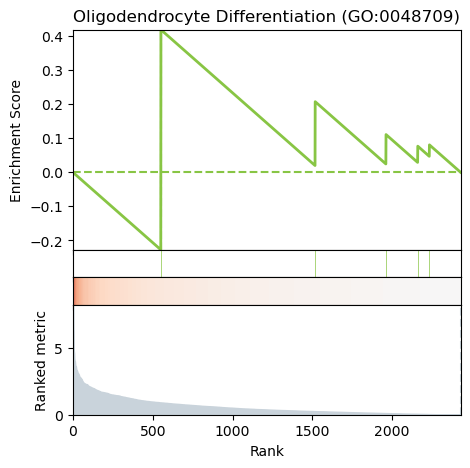

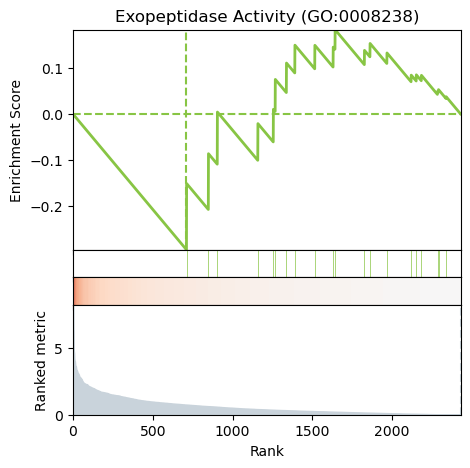

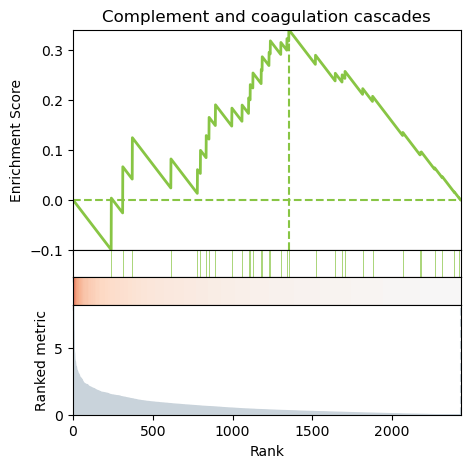

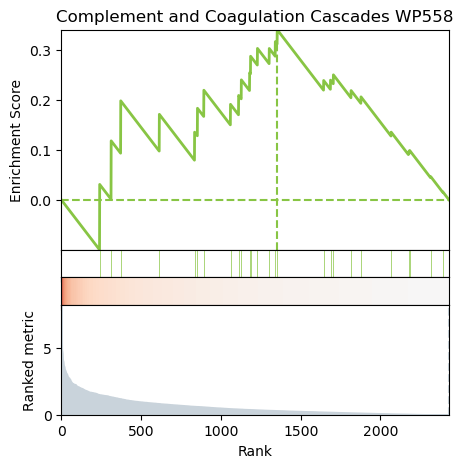

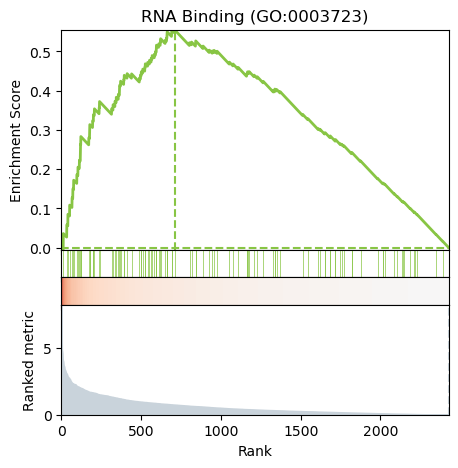

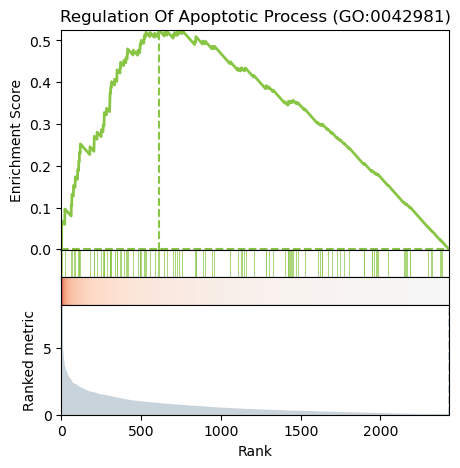

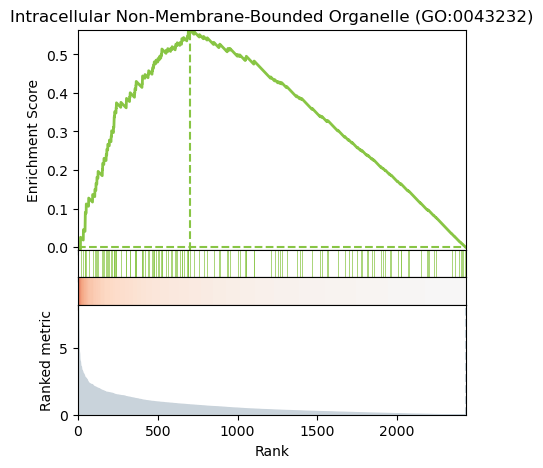

In [135]:
for x in Overall_Filtered_Pathways.sort_values(by="Absolute_NES", ascending=False)["Term"].tolist()[:10]:
    dc.plot_running_score(
        df=Overall_Regression_outputs,
        stat='-LogP',
        net=filtered_decoupler_frame,
        source='source',
        target='target',
        set_name=x
    )

In [136]:
Overall_Gene_series=Overall_Regression_outputs[["Beta"]].T.rename(index={'Beta': 'Systemic'})
Overall_Gene_series

Protein,AAAS,ABCC6,ABCC8,ABCF2,ABCF3,ABHD14B,ABHD5,ABI3BP,ABL1,ABO,...,ZNF75A,ZNF831,ZNF839,ZNRD2,ZNRF4,ZP3,ZPR1,ZRSR2,ZSWIM3,ZUP1
Systemic,-0.136352,0.130729,0.033261,0.044933,0.035739,0.097414,-0.039546,0.013505,0.076436,-0.014701,...,0.061944,0.048605,0.142471,0.026303,-0.06028,0.129364,0.044162,0.08257,-0.001688,-0.020095


In [137]:
Overall_Pathway_series=Overall_Filtered_Pathways.set_index("Term")[["NES"]].T.rename(index={'NES': 'Systemic'})
Overall_Pathway_series

Term,Complement and Coagulation Cascades WP558,Complement and coagulation cascades,Exopeptidase Activity (GO:0008238),Intracellular Non-Membrane-Bounded Organelle (GO:0043232),Oligodendrocyte Differentiation (GO:0048709),RNA Binding (GO:0003723),Regulation Of Apoptotic Process (GO:0042981)
Systemic,-1.684225,-1.707669,-1.926796,1.420636,-1.964341,1.466739,1.421191


In [138]:
Overall_Pathways[Overall_Pathways["FDR p-value"]<.05].sort_values(by="FDR p-value")["Term"].tolist()

['Complement and Coagulation Cascades WP558',
 'Complement and coagulation cascades',
 'Exopeptidase Activity (GO:0008238)',
 'Intracellular Non-Membrane-Bounded Organelle (GO:0043232)',
 'Oligodendrocyte Differentiation (GO:0048709)',
 'RNA Binding (GO:0003723)',
 'Regulation Of Apoptotic Process (GO:0042981)']

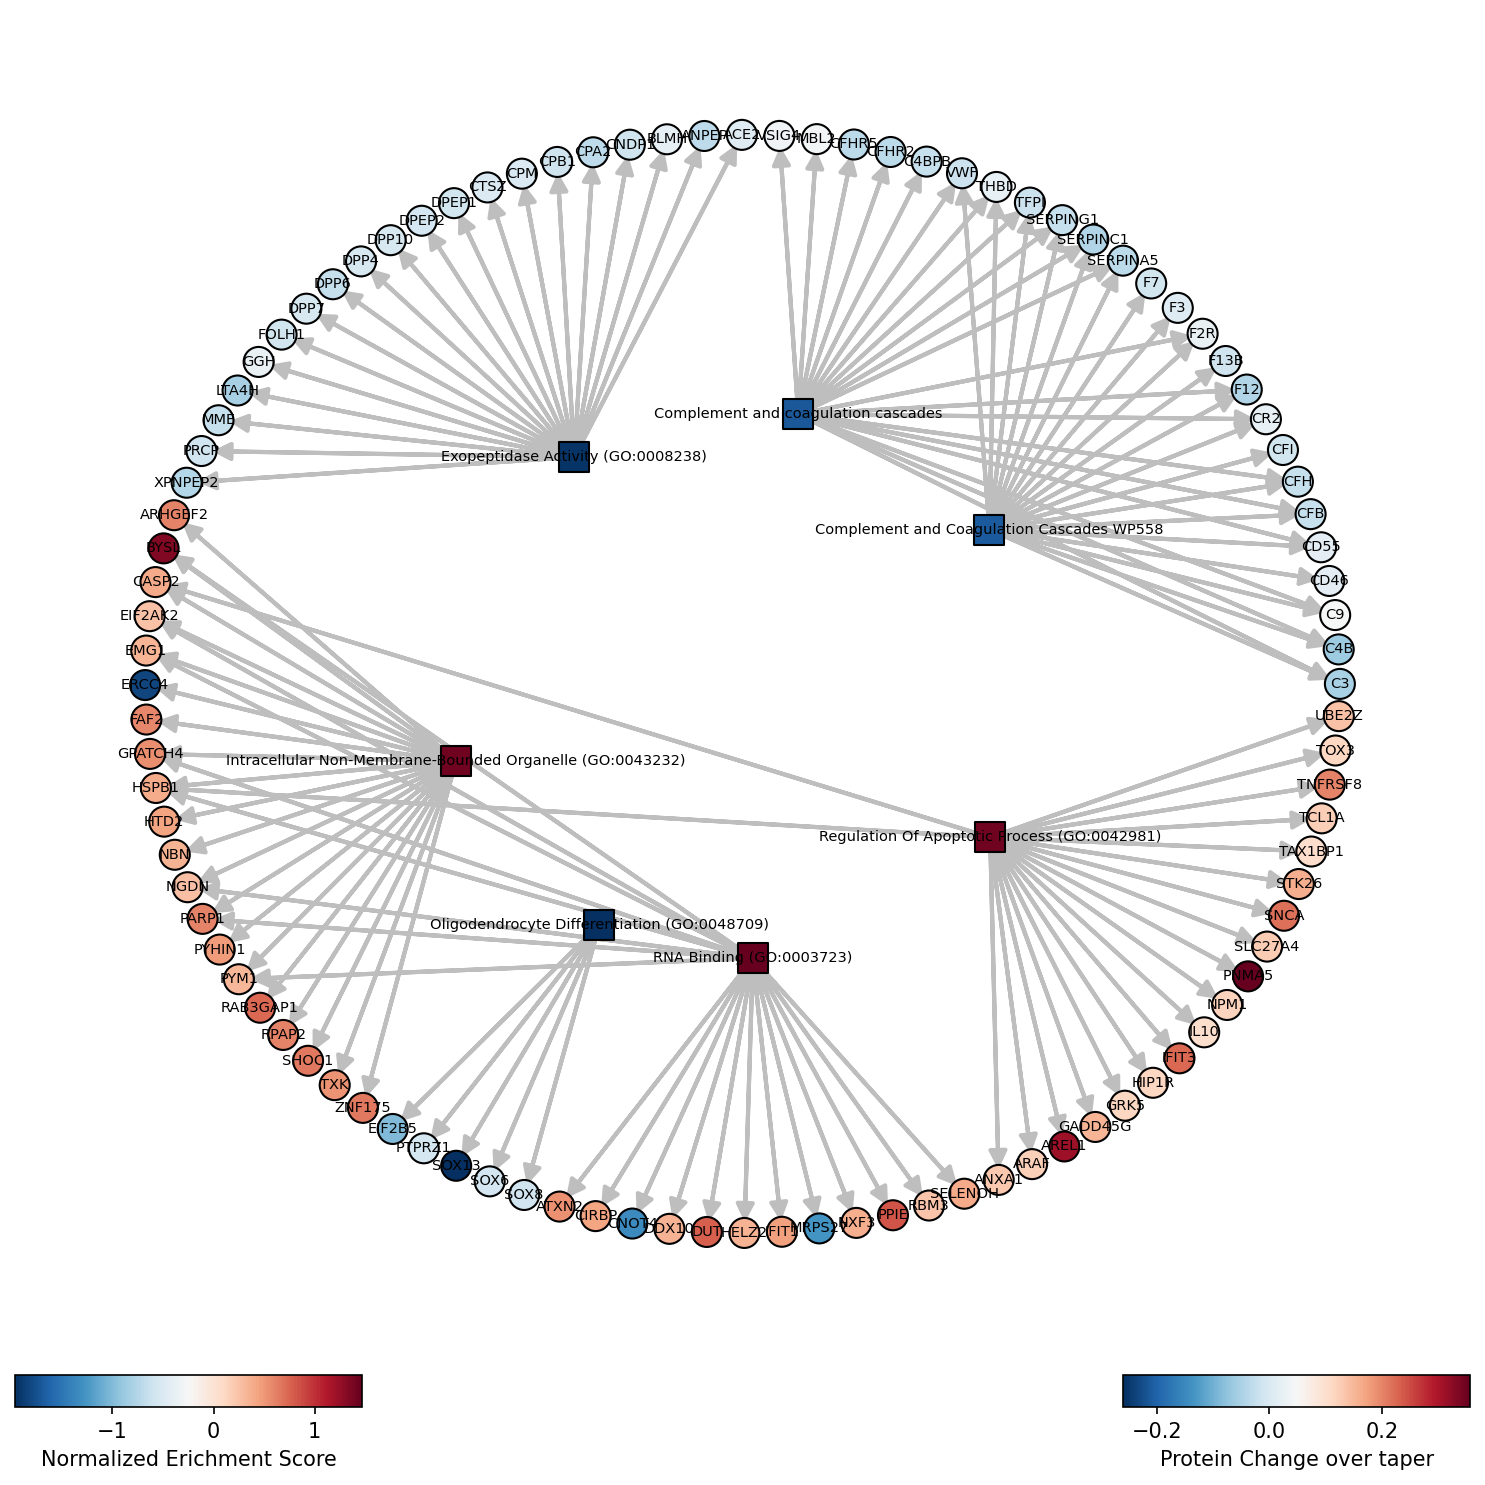

In [159]:
dc.plot_network(
    net=filtered_decoupler_frame,
    obs=Overall_Gene_series,
    act=Overall_Pathway_series,
    n_sources=Overall_Pathways[Overall_Pathways["FDR p-value"]<.05].sort_values(by="FDR p-value")["Term"].tolist(),
    n_targets=20,
    node_size=30,
    # s_cmap='Reds',
    t_cmap='RdBu_r',
    c_pos_w='gray',
    c_neg_w='gray',
    figsize=(10, 10),
    label_size=7,
    layout="rt_circular",
    s_label="Normalized Erichment Score",
    t_label="Protein Change over taper",
    save="Overall_Flarers_network.png"
)

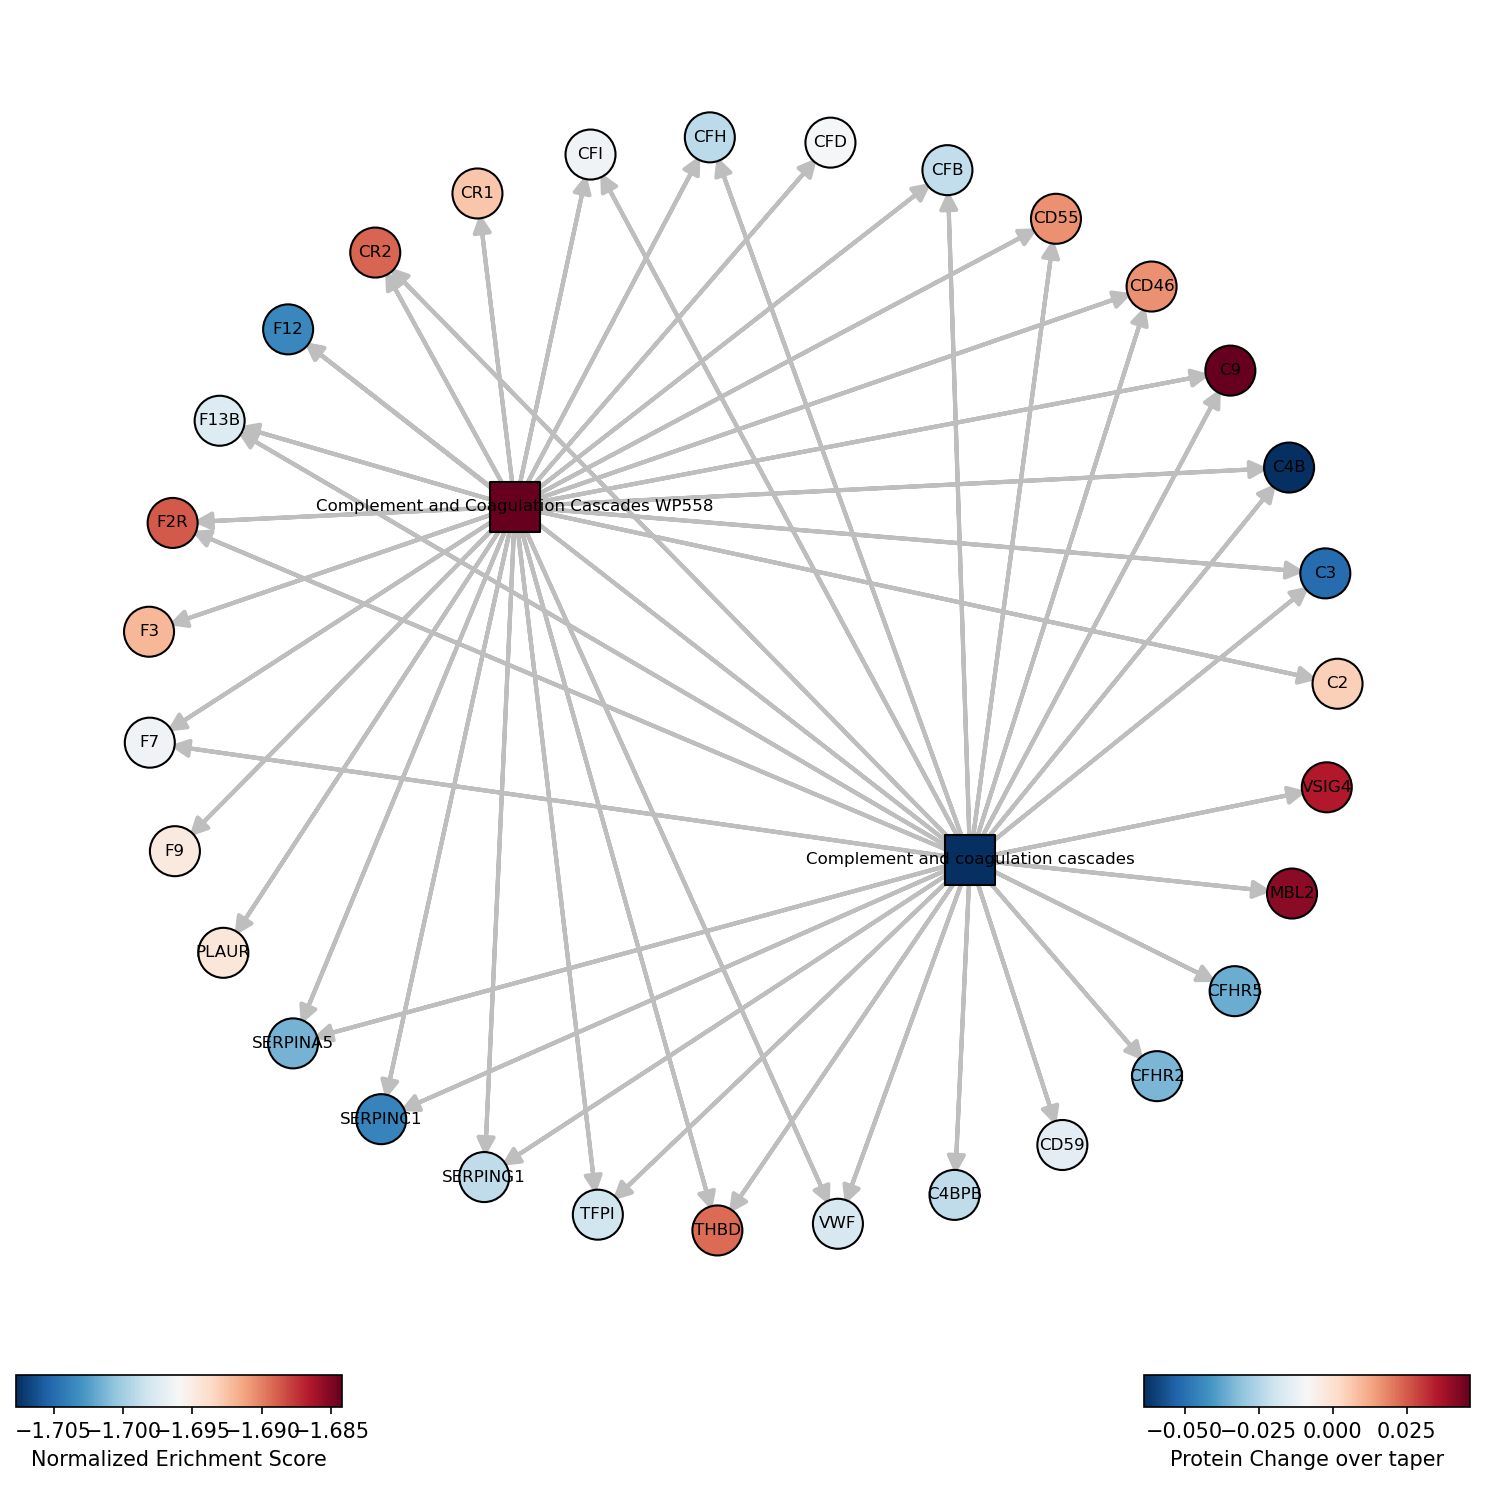

In [154]:
dc.plot_network(
    net=filtered_decoupler_frame,
    obs=Overall_Gene_series,
    act=Overall_Pathway_series,
    n_sources=['Complement and Coagulation Cascades WP558','Complement and coagulation cascades'],
    n_targets=25,
    node_size=50,
    # s_cmap='Reds',
    t_cmap='RdBu_r',
    c_pos_w='gray',
    c_neg_w='gray',
    figsize=(10, 10),
    label_size=8,
    layout="rt_circular",
    s_label="Normalized Erichment Score",
    t_label="Protein Change over taper",
    save="Overall_Flarers_Complement_network.png"
)